# 🤖 Deep RL with Stable-Baselines3 — From DQN and PPO to RLHF

> **What you'll learn:** why Q-tables stop working, how DQN makes neural-network Q-learning stable, how policy gradients (REINFORCE → A2C → PPO) and SAC work with the equations explained in plain English, how to use Stable-Baselines3 *correctly* (evaluation, callbacks that are really wired in, Monitor logs, fair vectorized-env timing, seeds), and how the same machinery trains LLMs with RLHF — and why DPO and GRPO are replacing parts of it.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate → 🔴 Advanced |
| **Time** | ~4 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Gymnasium & Q-Learning](01_Gymnasium_and_Q_Learning.ipynb) (returns, Bellman, Q-learning, terminated vs truncated) · [PyTorch](../04_Deep_Learning/02_PyTorch.ipynb) (tensors, autograd, optimizers) |
| **Tested with** | Python 3.12 · stable-baselines3 2.9 · gymnasium 1.3 · torch 2.14 (CPU) · numpy 2.5 · pandas 3.0 · matplotlib |
| **Interview relevance** | ⭐⭐⭐ High for LLM / applied-RL roles — "why does DQN need a target network?", "explain PPO's clipping", "what does the baseline do?", "how does RLHF work and why does DPO skip the reward model?", "how do you evaluate an RL agent?" |

## 🤔 What Is Deep Reinforcement Learning?

In the previous notebook the agent kept a **table** with one number per (state, action). That works for 16 or 500 states. But CartPole's state is 4 real numbers, an Atari frame is 100,800 pixels, and an LLM's "state" is every possible prompt — you can't list those in a table.

**Deep RL** replaces the table with a **neural network**:

```
 Tabular RL                              Deep RL
 ┌────────────────────┐                  state (any size) ──► [ neural network ] ──► Q-values for each action   (DQN)
 │ state │ a0  │ a1   │                                                        └──► action probabilities    (policy gradient, PPO)
 │   0   │ 0.1 │ 0.7  │                                                        └──► value estimate V(s)     (critic)
 │   1   │ 0.4 │ 0.2  │
 └────────────────────┘
```

**Analogy:** a table is a phone book — it only knows numbers it has seen. A neural network is an experienced driver — it has never seen *this exact* street corner, but it recognises "a junction with a car coming" and knows what to do. That ability to **generalise** to new states is the whole point.

**Stable-Baselines3 (SB3)** is a PyTorch library of reliable, tested implementations of the main algorithms (PPO, A2C, DQN, SAC, TD3, …) that work with any Gymnasium environment. In this notebook you'll build the core ideas yourself, then use SB3 the way professionals do.

## 🎯 Why It Matters

- **LLM post-training is RL.** ChatGPT-style assistants were aligned with **RLHF** (a reward model + PPO). Reasoning models are trained with **GRPO** and similar policy-gradient methods on verifiable rewards. **DPO** is a popular way to get RLHF-like results without running RL. You will be asked about all three in LLM-engineer interviews.
- **Robotics, games, and control** — locomotion, drone control, chip placement, and game agents use PPO and SAC.
- **The engineering is the hard part.** Deep RL is famously sensitive to seeds, hyperparameters, and subtle bugs (a callback that is never passed to training, an unfair speed benchmark, a curve that isn't real). This notebook shows each trap with measured numbers.
- **In interviews** expect: *explain DQN's replay buffer and target network*, *derive the policy-gradient intuition*, *why subtract a baseline*, *what PPO's clip does*, *on-policy vs off-policy sample efficiency*, *what the entropy term in SAC does*, *reward hacking*, and *RLHF vs DPO vs GRPO*.

## ✅ By the End You Can

- [ ] Explain why function approximation is needed and how DQN's experience replay and target network stabilise it
- [ ] Derive the policy-gradient estimator, implement REINFORCE with a baseline in PyTorch, and explain advantages, A2C, PPO's clipped objective, and GAE
- [ ] Train, evaluate, save, and load SB3 agents with correctly wired callbacks, Monitor logs, and real learning curves
- [ ] Benchmark vectorized environments fairly and report results across several seeds with mean ± std
- [ ] Explain RLHF (reward model + PPO), and how DPO and GRPO change the recipe

## 📋 Table of Contents

1. [Why Tables Don't Scale: Function Approximation](#1.-Why-Tables-Don't-Scale:-Function-Approximation-🟢)
2. [DQN: Experience Replay and Target Networks](#2.-DQN:-Experience-Replay-and-Target-Networks-🟡)
3. [Policy Gradients: Learning the Policy Directly](#3.-Policy-Gradients:-Learning-the-Policy-Directly-🟡)
4. [Variance Reduction: Reward-to-Go, Baselines, Advantages](#4.-Variance-Reduction:-Reward-to-Go,-Baselines,-Advantages-🟡)
5. [Actor–Critic and A2C](#5.-Actor–Critic-and-A2C-🟡)
6. [PPO: The Clipped Surrogate Objective and GAE](#6.-PPO:-The-Clipped-Surrogate-Objective-and-GAE-🔴)
7. [SAC for Continuous Control](#7.-SAC-for-Continuous-Control-🟡)
8. [SB3 in Practice: Train, Evaluate, Save, Load](#8.-SB3-in-Practice:-Train,-Evaluate,-Save,-Load-🟢)
9. [Callbacks Wired Correctly](#9.-Callbacks-Wired-Correctly-🟡)
10. [Monitor Logs and Real Learning Curves](#10.-Monitor-Logs-and-Real-Learning-Curves-🟢)
11. [Vectorized Environments: A Fair Speed Comparison](#11.-Vectorized-Environments:-A-Fair-Speed-Comparison-🟡)
12. [Hyperparameters, Devices, and Seeds](#12.-Hyperparameters,-Devices,-and-Seeds-🟡)
13. [From Games to LLMs: RLHF, DPO, and GRPO](#13.-From-Games-to-LLMs:-RLHF,-DPO,-and-GRPO-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-PPO-vs-DQN-vs-A2C-on-Two-Control-Tasks) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

- Everything trains on the **CPU**. For the small networks used in RL on vector observations, CPU is usually faster than a GPU because the time goes into stepping the environment and moving tiny tensors around — Section 12 **measures** this instead of assuming it.
- `torch.set_num_threads(1)` avoids thread start-up overhead for these tiny networks.
- Files (models, Monitor logs) go to `_outputs/rl_sb3/`. The whole notebook takes roughly 6–8 minutes on a laptop CPU.
- `check()` gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "stable-baselines3>=2.3" "gymnasium>=1.0" "torch>=2.2" pandas matplotlib

import copy
import shutil
import sys
import time
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import stable_baselines3 as sb3
import torch
import torch.nn as nn
import torch.nn.functional as F
from stable_baselines3 import A2C, DQN, PPO, SAC
from stable_baselines3.common.buffers import RolloutBuffer
from stable_baselines3.common.callbacks import BaseCallback, CallbackList, EvalCallback, StopTrainingOnRewardThreshold
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import load_results
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv

print(f"Python {sys.version.split()[0]} | SB3 {sb3.__version__} | Gymnasium {gym.__version__} | "
      f"PyTorch {torch.__version__} | NumPy {np.__version__}")

DEVICE = "cpu"                                   # measured in Section 12
torch.set_num_threads(1)
np.set_printoptions(precision=3, suppress=True)
OUTPUT_DIR = Path("_outputs") / "rl_sb3"         # files we write go here (ignored by git)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def fresh_dir(name):
    """An empty folder under OUTPUT_DIR (old Monitor files would otherwise mix with new runs)."""
    path = OUTPUT_DIR / name
    shutil.rmtree(path, ignore_errors=True)
    path.mkdir(parents=True)
    return path


def eval_env_for(env_id, seed):
    """A separate, Monitor-wrapped, seeded evaluation environment."""
    return make_vec_env(env_id, n_envs=1, seed=seed)


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(got, torch.Tensor):
        got = got.detach().cpu().numpy()
    got_arr, exp_arr = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
    if got_arr.shape != exp_arr.shape:
        raise AssertionError(f"❌ {name}: shape {got_arr.shape}, expected {exp_arr.shape}. {hint}")
    assert np.allclose(got_arr, exp_arr, atol=1e-4), f"❌ {name}: values are not quite right. {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | SB3 2.9.0 | Gymnasium 1.3.0 | PyTorch 2.14.0 | NumPy 2.5.3


## 1. Why Tables Don't Scale: Function Approximation 🟢

To use a Q-table on CartPole we would have to **discretise** each of its 4 continuous numbers into bins. The table grows as $\text{bins}^{\text{dimensions}}$ — the *curse of dimensionality* — and most cells are never visited, so the agent learns nothing about them.

In [2]:
cart = gym.make("CartPole-v1")
bounds = np.array([[-2.4, 2.4], [-3.0, 3.0], [-0.21, 0.21], [-3.5, 3.5]])      # clipped ranges for the 4 numbers

for bins in [10, 20, 50]:
    print(f"{bins:>2} bins per dimension → {bins ** 4:>10,} states × 2 actions = {2 * bins ** 4:>12,} table entries")

# How much of a 10-bin table does real experience actually cover?
bins = 10
edges = [np.linspace(lo, hi, bins + 1)[1:-1] for lo, hi in bounds]
visited, n_steps = set(), 0
obs, _ = cart.reset(seed=0)
cart.action_space.seed(0)
for _ in range(20_000):
    visited.add(tuple(int(np.digitize(x, e)) for x, e in zip(obs, edges)))
    obs, _, terminated, truncated, _ = cart.step(cart.action_space.sample())
    n_steps += 1
    if terminated or truncated:
        obs, _ = cart.reset()
print(f"\nafter {n_steps:,} random steps, only {len(visited):,} of {bins ** 4:,} cells ({len(visited) / bins ** 4:.1%}) were ever visited")

10 bins per dimension →     10,000 states × 2 actions =       20,000 table entries
20 bins per dimension →    160,000 states × 2 actions =      320,000 table entries
50 bins per dimension →  6,250,000 states × 2 actions =   12,500,000 table entries

after 20,000 random steps, only 335 of 10,000 cells (3.4%) were ever visited


A neural network needs no bins. A small multilayer perceptron maps the 4 numbers straight to 2 Q-values, with a fixed number of parameters no matter how many states exist, and **similar states give similar outputs** — learning about one state teaches it about its neighbours.

In [3]:
q_network = nn.Sequential(nn.Linear(4, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 2))
n_params = sum(p.numel() for p in q_network.parameters())
state = torch.tensor([[0.01, 0.2, 0.03, -0.1]])
nearby = state + 0.001
with torch.no_grad():
    print(f"Q-network parameters: {n_params:,} (covers infinitely many states)")
    print("Q(state)  :", q_network(state).numpy().round(4))
    print("Q(nearby) :", q_network(nearby).numpy().round(4), "← almost identical: generalisation for free")

Q-network parameters: 4,610 (covers infinitely many states)
Q(state)  : [[-0.046 -0.064]]
Q(nearby) : [[-0.046 -0.064]] ← almost identical: generalisation for free


### ✍️ Your Turn

**Acrobot-v1** has 6 continuous observation numbers and 3 actions. How many Q-table entries would you need with **10 bins per dimension**? Store it in `acrobot_table_entries`.

In [4]:
acrobot_table_entries = None  # TODO: your code here
check("acrobot_table_entries", acrobot_table_entries, 3_000_000, hint="bins ** n_dims * n_actions")

⏳ acrobot_table_entries: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
acro = gym.make("Acrobot-v1")
acrobot_table_entries = 10 ** acro.observation_space.shape[0] * acro.action_space.n
check("acrobot_table_entries", acrobot_table_entries, 3_000_000)
```

Three million entries for a two-link pendulum — and almost all of them would stay unvisited.
</details>

> 💡 **Interview angle:** "Why deep RL instead of tabular?" — the state space is continuous or huge, tables grow exponentially with dimensions and can't generalise; a function approximator shares knowledge between similar states. The price is stability: bootstrapping + off-policy data + function approximation (the "deadly triad") can diverge.

## 2. DQN: Experience Replay and Target Networks 🟡

**DQN** (Deep Q-Network, Mnih et al. 2015 — the Atari paper) is Q-learning with a neural network $Q_\theta$. It minimises the squared (in practice Huber) TD error:

$$L(\theta) = \Big(\underbrace{r + \gamma\,(1 - \text{terminated})\,\max_{a'} Q_{\bar\theta}(s', a')}_{\text{target, uses the frozen target network } \bar\theta} - Q_\theta(s, a)\Big)^2$$

Naively plugging a network into Q-learning is unstable. DQN adds two tricks:

| Trick | Problem it solves | Plain English |
|---|---|---|
| **Experience replay** | consecutive transitions are highly correlated, and each one is used once and thrown away | store transitions in a big buffer and train on **random mini-batches** — like studying from shuffled flashcards instead of re-reading the last page |
| **Target network** $Q_{\bar\theta}$ | the target depends on the same weights you're updating, so every step **moves the goalposts** | compute targets with a **frozen copy** that's only synced every N steps — aim at a target that stays still for a while |

Both are needed: replay fixes the *data* problem (correlation, reuse), the target network fixes the *optimisation* problem (a moving target). Let's train SB3's DQN on CartPole (hyperparameters from the [RL Baselines3 Zoo](https://github.com/DLR-RM/rl-baselines3-zoo)) and then look inside.

In [5]:
DQN_CARTPOLE = dict(learning_rate=2.3e-3, batch_size=64, buffer_size=100_000, learning_starts=1000, gamma=0.99,
                    target_update_interval=10, train_freq=256, gradient_steps=128, exploration_fraction=0.16,
                    exploration_final_eps=0.04, policy_kwargs=dict(net_arch=[256, 256]))

dqn_model = DQN("MlpPolicy", make_vec_env("CartPole-v1", n_envs=1, seed=0), seed=0, device=DEVICE, **DQN_CARTPOLE)
start = time.perf_counter()
dqn_model.learn(total_timesteps=30_000)
print(f"trained DQN for 30,000 steps in {time.perf_counter() - start:.1f} s")

random_mean, random_std = evaluate_policy(DQN("MlpPolicy", "CartPole-v1", seed=0, device=DEVICE),
                                          eval_env_for("CartPole-v1", 1000), n_eval_episodes=20)
dqn_mean, dqn_std = evaluate_policy(dqn_model, eval_env_for("CartPole-v1", 1000), n_eval_episodes=20)
print(f"untrained network: {random_mean:.1f} ± {random_std:.1f} | DQN after 30k steps: {dqn_mean:.1f} ± {dqn_std:.1f} (max 500)")

trained DQN for 30,000 steps in 6.5 s
untrained network: 9.6 ± 0.6 | DQN after 30k steps: 84.8 ± 20.7 (max 500)


In [6]:
buffer = dqn_model.replay_buffer
n_stored = buffer.size()
angles = buffer.observations[:n_stored, 0, 2]                     # pole angle of every stored transition, in order
shuffled = angles[np.random.default_rng(0).permutation(n_stored)]
print(f"replay buffer holds {n_stored:,} transitions; observation array shape {buffer.observations.shape}")
print(f"correlation between consecutive transitions : {np.corrcoef(angles[:-1], angles[1:])[0, 1]:+.3f}")
print(f"correlation after random sampling            : {np.corrcoef(shuffled[:-1], shuffled[1:])[0, 1]:+.3f}")
print(f"stored episode ends: {int(buffer.dones[:n_stored].sum())}, of which time-limit truncations: "
      f"{int(buffer.timeouts[:n_stored].sum())} (SB3 keeps bootstrapping on those)")

replay buffer holds 30,208 transitions; observation array shape (100000, 1, 4)
correlation between consecutive transitions : +0.979
correlation after random sampling            : -0.008
stored episode ends: 412, of which time-limit truncations: 2 (SB3 keeps bootstrapping on those)


Now the moving-target problem, measured. We take one replay batch and do 50 gradient steps on a copy of the Q-network, computing targets either with the **same network** we're training or with a **frozen copy**.

In [7]:
batch = buffer.sample(256)
gamma = dqn_model.gamma


def td_targets(net):
    with torch.no_grad():
        next_q = net(batch.next_observations).max(dim=1).values
    return batch.rewards.flatten() + gamma * (1 - batch.dones.flatten()) * next_q     # dones = terminated only


for use_frozen_target in [False, True]:
    online = copy.deepcopy(dqn_model.q_net)
    target_net = copy.deepcopy(online)
    optimizer = torch.optim.Adam(online.parameters(), lr=1e-3)
    initial_targets = td_targets(target_net if use_frozen_target else online)
    for _ in range(50):
        current_targets = td_targets(target_net if use_frozen_target else online)
        q_taken = online(batch.observations).gather(1, batch.actions.long()).flatten()
        loss = F.smooth_l1_loss(q_taken, current_targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    drift = (td_targets(target_net if use_frozen_target else online) - initial_targets).abs().mean().item()
    label = "frozen target network" if use_frozen_target else "targets from the online network"
    print(f"{label:32s}: targets moved by {drift:.3f} on average during 50 updates")

targets from the online network : targets moved by 16.816 on average during 50 updates
frozen target network           : targets moved by 0.000 on average during 50 updates


With the online network the regression targets shift while we chase them; with a frozen target network they don't. Later improvements you should be able to name: **Double DQN** (select the next action with the online net, evaluate it with the target net — fixes over-estimation), **Dueling** networks ($Q = V + A$), **prioritised replay**, **n-step returns**, and Rainbow (all combined). SB3's `DQN` is the original algorithm with a target network and Huber loss.

> 💡 **Interview angle:** "Why does DQN need both a replay buffer and a target network?" — replay breaks correlation and reuses data (i.i.d.-like mini-batches); the target network keeps the TD target fixed for many updates so training doesn't chase itself. Remove either and learning becomes unstable.

## 3. Policy Gradients: Learning the Policy Directly 🟡

Value-based methods learn Q and act greedily. **Policy-gradient** methods instead learn a policy network $\pi_\theta(a \mid s)$ that outputs action probabilities, and nudge $\theta$ to make good actions more likely.

We want to maximise the expected return $J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}[R(\tau)]$. We can't differentiate through the environment, but the **log-derivative trick** ($\nabla \pi = \pi\, \nabla \log \pi$) gives the **policy gradient theorem**:

$$\nabla_\theta J(\theta) = \mathbb{E}\Big[\sum_t \nabla_\theta \log \pi_\theta(a_t \mid s_t)\; G_t\Big]$$

**Plain English:** for every action you took, push up its log-probability **in proportion to how good the outcome was**. Good outcomes → that action becomes more likely; bad outcomes → less likely. This is **REINFORCE** (Williams, 1992). It needs only samples — no model, no Q-table.

**Sanity check on a bandit** (synthetic, so the exact answer is known): 3 slot machines paying 1, 2, and 3 on average, and a softmax policy. PyTorch autograd gives the *exact* gradient of expected reward; the REINFORCE *estimate* only uses sampled actions and noisy rewards. They should agree.

In [8]:
arm_means = torch.tensor([1.0, 2.0, 3.0])
logits = torch.tensor([0.5, 0.0, -0.5], requires_grad=True)       # currently prefers the WORST arm

expected_reward = (torch.softmax(logits, dim=0) * arm_means).sum()
exact_gradient, = torch.autograd.grad(expected_reward, logits)

gen = torch.Generator().manual_seed(0)
n_samples = 200_000
probs = torch.softmax(logits.detach(), dim=0)
actions = torch.multinomial(probs, n_samples, replacement=True, generator=gen)
rewards = arm_means[actions] + torch.randn(n_samples, generator=gen)          # noisy rewards
score = F.one_hot(actions, 3).float() - probs                                 # ∇ log softmax(θ)[a] = onehot(a) − π
reinforce_gradient = (score * rewards[:, None]).mean(dim=0)

print("policy probabilities :", probs.numpy())
print("exact gradient       :", exact_gradient.numpy())
print("REINFORCE estimate   :", reinforce_gradient.numpy())
assert torch.allclose(exact_gradient, reinforce_gradient, atol=0.02)
print("✅ the sampled score-function estimate matches the true gradient — and it raises the logit of the best arm")

policy probabilities : [0.506 0.307 0.186]
exact gradient       : [-0.344  0.098  0.246]
REINFORCE estimate   : [-0.343  0.096  0.247]
✅ the sampled score-function estimate matches the true gradient — and it raises the logit of the best arm


### ✍️ Your Turn

For a softmax policy with logits `[2.0, 1.0, 0.0]`, compute $\nabla_{\text{logits}} \log \pi(a = 0)$ — the "score" REINFORCE multiplies by the return. Store it in `score_a0`.

In [9]:
score_a0 = None  # TODO: your code here
check("score_a0", score_a0, [0.334759, -0.244728, -0.090031], hint="onehot(a) − softmax(logits), or autograd on log_softmax(logits)[0].")

⏳ score_a0: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
z = torch.tensor([2.0, 1.0, 0.0], requires_grad=True)
score_a0, = torch.autograd.grad(torch.log_softmax(z, dim=0)[0], z)
check("score_a0", score_a0, [0.334759, -0.244728, -0.090031])

# closed form: onehot(0) − softmax(z)
check("score_a0 (closed form)", F.one_hot(torch.tensor(0), 3) - torch.softmax(z.detach(), dim=0), [0.334759, -0.244728, -0.090031])
```
The chosen action's logit goes up, the others go down, weighted by how likely they currently are.
</details>

> 💡 **Interview angle:** "Explain the policy gradient theorem intuitively." — increase the log-probability of actions in proportion to the return that followed; the log-derivative trick turns "gradient of an expectation" into "expectation of a gradient", so sampled episodes give an unbiased estimate without differentiating the environment.

## 4. Variance Reduction: Reward-to-Go, Baselines, Advantages 🟡

REINFORCE is unbiased but **very noisy**: if every reward is positive, *every* action gets pushed up, just some more than others. Three fixes, each keeping the gradient unbiased:

1. **Reward-to-go:** an action can only affect rewards *after* it, so weight $\nabla \log \pi(a_t \mid s_t)$ by $G_t$ (future rewards) instead of the whole episode's return.
2. **Baseline:** subtract any $b(s_t)$ that doesn't depend on the action: $\nabla \log \pi(a_t \mid s_t)\,(G_t - b(s_t))$. Its expected contribution is zero because $\mathbb{E}_a[\nabla \log \pi(a \mid s)] = \nabla \sum_a \pi(a \mid s) = \nabla 1 = 0$.
3. **Advantage:** the best common baseline is the value $V(s_t)$, giving the **advantage** $A_t = G_t - V(s_t)$ — *"how much better than usual was this action?"*

Measured on the bandit: the per-sample gradient estimates with and without a baseline have the **same mean** but very different **variance**.

In [10]:
baseline = (probs * arm_means).sum()                                   # expected reward under the current policy
per_sample_plain = score * rewards[:, None]
per_sample_baseline = score * (rewards - baseline)[:, None]

print("mean gradient without baseline:", per_sample_plain.mean(0).numpy())
print("mean gradient with baseline   :", per_sample_baseline.mean(0).numpy())
var_plain = per_sample_plain.var(0).sum().item()
var_baseline = per_sample_baseline.var(0).sum().item()
print(f"total variance without baseline: {var_plain:.3f} | with baseline: {var_baseline:.3f} "
      f"→ {var_plain / var_baseline:.1f}× lower variance, so far fewer samples are needed for the same accuracy")

mean gradient without baseline: [-0.343  0.096  0.247]
mean gradient with baseline   : [-0.343  0.097  0.246]
total variance without baseline: 3.263 | with baseline: 0.867 → 3.8× lower variance, so far fewer samples are needed for the same accuracy


### ✍️ Your Turn

Compute advantages `returns − values` and then **normalise** them to mean 0 and standard deviation 1 (use the population std, `np.std`). Most PPO implementations normalise advantages per mini-batch like this. Store the result in `normalized_adv`.

In [11]:
returns_ex = np.array([10.0, 8.0, 12.0, 6.0])
values_ex = np.array([9.0, 9.0, 9.0, 9.0])
normalized_adv = None  # TODO: your code here
check("normalized_adv", normalized_adv, [0.447214, -0.447214, 1.341641, -1.341641], hint="adv = returns − values; (adv − adv.mean()) / adv.std()")

⏳ normalized_adv: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
returns_ex = np.array([10.0, 8.0, 12.0, 6.0])
values_ex = np.array([9.0, 9.0, 9.0, 9.0])
adv = returns_ex - values_ex                      # [1, -1, 3, -3]
normalized_adv = (adv - adv.mean()) / adv.std()   # std = sqrt(5)
check("normalized_adv", normalized_adv, [0.447214, -0.447214, 1.341641, -1.341641])
```
SB3's PPO does the same with `advantages.std() + 1e-8` (a PyTorch sample std) per mini-batch.
</details>

> 💡 **Interview angle:** "Why doesn't a baseline bias the policy gradient?" — because $\mathbb{E}_{a \sim \pi}[\nabla \log \pi(a \mid s)\, b(s)] = b(s)\,\nabla \sum_a \pi(a \mid s) = 0$. It only removes variance. Using $V(s)$ as the baseline gives the advantage.

## 5. Actor–Critic and A2C 🟡

REINFORCE waits for the episode to end to compute $G_t$. **Actor–critic** methods learn a **critic** $V_\phi(s)$ alongside the **actor** $\pi_\theta$ and use it to estimate advantages from short snippets of experience:

$$A_t \approx r_t + \gamma V_\phi(s_{t+1}) - V_\phi(s_t) \quad \text{(1-step)}, \qquad \text{or an } n\text{-step version}$$

**A2C** (Advantage Actor–Critic, the synchronous version of A3C) runs several environments in parallel, collects `n_steps` from each, and minimises

$$L = \underbrace{-\,\log \pi_\theta(a_t \mid s_t)\,A_t}_{\text{actor}} \;+\; c_v \underbrace{(G_t - V_\phi(s_t))^2}_{\text{critic}} \;-\; c_e \underbrace{\mathcal{H}[\pi_\theta(\cdot \mid s_t)]}_{\text{entropy bonus (exploration)}}$$

**Analogy:** the actor is the player, the critic is the coach who says "that was better than I expected" *during* the game, not only at the final whistle. Bias goes up (the coach can be wrong), variance goes down.

In [12]:
a2c_model = A2C("MlpPolicy", make_vec_env("CartPole-v1", n_envs=8, seed=0), seed=0, device=DEVICE)
print(a2c_model.policy)                           # shared MLP → action_net (actor) and value_net (critic)
start = time.perf_counter()
a2c_model.learn(total_timesteps=30_000)
a2c_mean, a2c_std = evaluate_policy(a2c_model, eval_env_for("CartPole-v1", 2000), n_eval_episodes=20)
print(f"\nA2C: 30,000 steps with 8 parallel envs in {time.perf_counter() - start:.1f} s → eval return {a2c_mean:.1f} ± {a2c_std:.1f}")
print(f"defaults: n_steps={a2c_model.n_steps} per env (rollout of {a2c_model.n_steps * a2c_model.n_envs} steps), "
      f"gae_lambda={a2c_model.gae_lambda}, ent_coef={a2c_model.ent_coef}, vf_coef={a2c_model.vf_coef}")

ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=4, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=4, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=64, out_features=2, bias=True)
  (value_net): Linear(in_features=64, out_features=1, bias=True)
)



A2C: 30,000 steps with 8 parallel envs in 1.2 s → eval return 369.2 ± 66.5
defaults: n_steps=5 per env (rollout of 40 steps), gae_lambda=1.0, ent_coef=0.0, vf_coef=0.5


> 💡 **Interview angle:** "What is an actor–critic?" — a policy network (actor) trained with advantages estimated by a value network (critic). It trades a little bias for much lower variance than REINFORCE and can update before episodes end. A2C/A3C, PPO, SAC, and the RLHF PPO setup are all actor–critics.

## 6. PPO: The Clipped Surrogate Objective and GAE 🔴

A2C uses each batch of experience for **one** gradient step — wasteful, but taking many steps on the same data can push the policy so far that it collapses. **PPO** (Proximal Policy Optimization, Schulman et al. 2017) reuses each batch for several epochs **safely**.

**Probability ratio** between the new policy and the policy that collected the data:
$$r_t(\theta) = \frac{\pi_\theta(a_t \mid s_t)}{\pi_{\theta_\text{old}}(a_t \mid s_t)}$$

**Clipped surrogate objective** (maximised):
$$L^{\text{CLIP}}(\theta) = \mathbb{E}_t\Big[\min\big(r_t(\theta)\,A_t,\;\; \text{clip}(r_t(\theta),\, 1-\varepsilon,\, 1+\varepsilon)\,A_t\big)\Big]$$

**Plain English:**
- If an action was **better than expected** ($A_t > 0$), make it more likely — but once it is already $1+\varepsilon$ times more likely than before, stop getting credit for pushing further.
- If it was **worse** ($A_t < 0$), make it less likely — but stop once it is $1-\varepsilon$ times as likely.
- The `min` makes it *pessimistic*: clipping can only remove incentive, never add it. That keeps each update "proximal" (close to the old policy) without TRPO's complicated constraint.

The full PPO loss adds the critic and an entropy bonus: $L = -L^{\text{CLIP}} + c_v\,(V_\phi(s_t) - \hat R_t)^2 - c_e\,\mathcal{H}[\pi_\theta]$.

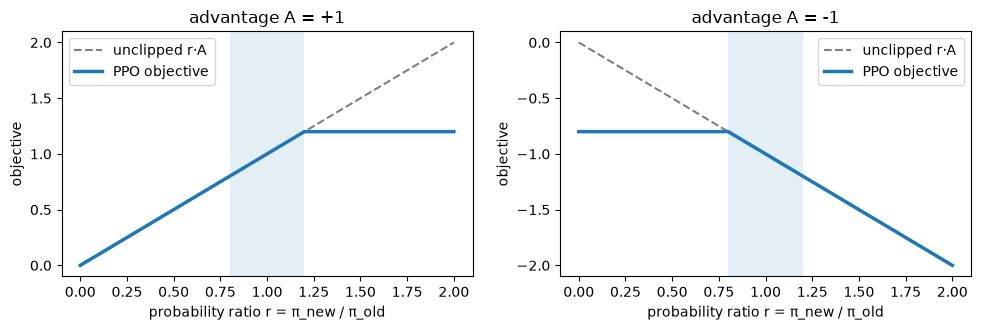

A>0: objective flat for r > 1.2 → no gradient to push further | A<0: flat for r < 0.8


In [13]:
def ppo_clip_objective(ratio, advantage, clip_range=0.2):
    unclipped = ratio * advantage
    clipped = np.clip(ratio, 1 - clip_range, 1 + clip_range) * advantage
    return np.minimum(unclipped, clipped)


ratios = np.linspace(0.0, 2.0, 201)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharex=True)
for ax, adv in zip(axes, [1.0, -1.0]):
    ax.plot(ratios, ratios * adv, "--", c="gray", label="unclipped r·A")
    ax.plot(ratios, ppo_clip_objective(ratios, adv), lw=2.5, label="PPO objective")
    ax.axvspan(0.8, 1.2, alpha=0.12)
    ax.set(title=f"advantage A = {adv:+.0f}", xlabel="probability ratio r = π_new / π_old", ylabel="objective")
    ax.legend()
plt.tight_layout()
plt.show()
print("A>0: objective flat for r > 1.2 → no gradient to push further | A<0: flat for r < 0.8")

### Generalized Advantage Estimation (GAE)

How should we estimate $A_t$? The 1-step TD error $\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$ has low variance but is biased; the full Monte Carlo return is unbiased but noisy. **GAE** (Schulman et al. 2016) blends all n-step estimates with a decay $\lambda$:

$$\hat A_t = \sum_{l=0}^{\infty} (\gamma\lambda)^l\, \delta_{t+l} \qquad \Longleftrightarrow \qquad \hat A_t = \delta_t + \gamma\lambda\,(1 - \text{done}_{t+1})\,\hat A_{t+1}$$

$\lambda = 0$ → pure TD (low variance, more bias); $\lambda = 1$ → Monte Carlo (unbiased, high variance). PPO's default is $\lambda = 0.95$. The value target is $\hat R_t = \hat A_t + V(s_t)$.

Let's implement it in a backward loop and **assert it matches SB3's own `RolloutBuffer`** on random data with an episode boundary in the middle.

In [14]:
def compute_gae(rewards, values, episode_starts, last_value, last_done, gamma=0.99, gae_lambda=0.95):
    """GAE over one rollout. episode_starts[t] = 1 if step t began a new episode."""
    advantages = np.zeros(len(rewards))
    running = 0.0
    for t in reversed(range(len(rewards))):
        if t == len(rewards) - 1:
            next_non_terminal, next_value = 1.0 - last_done, last_value
        else:
            next_non_terminal, next_value = 1.0 - episode_starts[t + 1], values[t + 1]
        delta = rewards[t] + gamma * next_value * next_non_terminal - values[t]
        running = delta + gamma * gae_lambda * next_non_terminal * running
        advantages[t] = running
    return advantages, advantages + values                          # advantages, value targets


rng = np.random.default_rng(0)
T = 8
fake_rewards, fake_values = rng.normal(size=T), rng.normal(size=T)
fake_starts = np.array([1, 0, 0, 1, 0, 0, 0, 0], dtype=np.float32)    # a new episode begins at step 3
last_value, last_done = 0.5, False

sb3_buffer = RolloutBuffer(T, gym.spaces.Box(-1, 1, (2,)), gym.spaces.Discrete(2), device="cpu", gamma=0.9, gae_lambda=0.8, n_envs=1)
for t in range(T):
    sb3_buffer.add(np.zeros((1, 2), dtype=np.float32), np.zeros((1, 1)), np.array([fake_rewards[t]], dtype=np.float32),
                   np.array([fake_starts[t]]), torch.tensor([fake_values[t]]), torch.zeros(1))
sb3_buffer.compute_returns_and_advantage(torch.tensor([last_value]), np.array([last_done]))

ours_adv, ours_ret = compute_gae(fake_rewards, fake_values, fake_starts, last_value, float(last_done), gamma=0.9, gae_lambda=0.8)
assert np.allclose(ours_adv, sb3_buffer.advantages.ravel(), atol=1e-5)
assert np.allclose(ours_ret, sb3_buffer.returns.ravel(), atol=1e-5)
print("our GAE advantages:", ours_adv.round(3))
print("SB3 advantages    :", sb3_buffer.advantages.ravel().round(3))
print("✅ identical to SB3's implementation")

our GAE advantages: [0.758 1.482 1.264 0.115 2.978 1.924 3.424 2.129]
SB3 advantages    : [0.758 1.482 1.264 0.115 2.978 1.924 3.424 2.129]
✅ identical to SB3's implementation


### ✍️ Your Turn

With `clip_range = 0.2`, compute the PPO objective for two samples: **(a)** ratio 1.5 with advantage +2, **(b)** ratio 0.5 with advantage −1. Store `[a, b]` in `clip_values`.

In [15]:
clip_values = None  # TODO: your code here
check("clip_values", clip_values, [2.4, -0.8], hint="min(r·A, clip(r, 0.8, 1.2)·A) for each sample.")

⏳ clip_values: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
clip_values = ppo_clip_objective(np.array([1.5, 0.5]), np.array([2.0, -1.0]), clip_range=0.2)
check("clip_values", clip_values, [2.4, -0.8])
```

(a) min(3.0, 1.2·2 = 2.4) = 2.4 — the extra push beyond 1.2× is clipped away.
(b) min(−0.5, 0.8·(−1) = −0.8) = −0.8 — the bad action is already below 0.8× its old probability, so the `min` picks the clipped branch, which is constant in the ratio: **zero gradient**, no incentive to push it down even further.
</details>

> 💡 **Interview angle:** "Why does PPO clip?" — to reuse a batch for several epochs without the policy moving too far from the one that collected the data (the importance ratio would become unreliable and performance can collapse). Clipping removes the incentive to move beyond $[1-\varepsilon, 1+\varepsilon]$; the `min` makes the bound pessimistic. Mention GAE(λ) for advantages and that the RLHF PPO adds a KL penalty to a reference model.

## 7. SAC for Continuous Control 🟡

DQN needs $\max_a Q(s,a)$, which is easy for 2 actions but not for a **continuous** action like a torque in $[-2, 2]$. **SAC** (Soft Actor–Critic, Haarnoja et al. 2018) is the go-to off-policy algorithm for continuous control:

- **Maximum-entropy objective:** $J(\pi) = \mathbb{E}\big[\sum_t r_t + \alpha\, \mathcal{H}(\pi(\cdot \mid s_t))\big]$ — earn reward *and* stay as random as possible. The **temperature** $\alpha$ sets the trade-off; SB3 tunes it automatically (`ent_coef="auto"`) toward a target entropy of $-\dim(\mathcal{A})$.
- **Why entropy helps:** built-in exploration, robustness, and it avoids collapsing early onto one action.
- **Twin critics:** two Q-networks, use the minimum to curb over-estimation (as in TD3); soft target updates with $\tau = 0.005$.
- **Off-policy with a replay buffer** → far more sample-efficient than PPO on robotics-style tasks.

**Pendulum-v1:** swing a pendulum upright with a continuous torque. Reward is always ≤ 0 (0 = perfectly upright, no effort); episodes last 200 steps.

In [16]:
pendulum = gym.make("Pendulum-v1")
print("action space:", pendulum.action_space, "| episode length:", pendulum.spec.max_episode_steps)
pendulum.action_space.seed(0)
random_returns = []
obs, _ = pendulum.reset(seed=0)
for _ in range(10):
    total, done = 0.0, False
    while not done:
        obs, reward, terminated, truncated, _ = pendulum.step(pendulum.action_space.sample())
        total, done = total + reward, terminated or truncated
    random_returns.append(total)
    obs, _ = pendulum.reset()
print(f"random torques: {np.mean(random_returns):.0f} ± {np.std(random_returns):.0f}")

sac_model = SAC("MlpPolicy", make_vec_env("Pendulum-v1", n_envs=1, seed=0), learning_starts=1000, seed=0, device=DEVICE)
start = time.perf_counter()
sac_model.learn(total_timesteps=8_000)
sac_mean, sac_std = evaluate_policy(sac_model, eval_env_for("Pendulum-v1", 3000), n_eval_episodes=10)
print(f"SAC after 8,000 steps ({time.perf_counter() - start:.0f} s): {sac_mean:.0f} ± {sac_std:.0f} "
      f"| learned entropy coefficient α = {torch.exp(sac_model.log_ent_coef).item():.3f} "
      f"| target entropy = {sac_model.target_entropy}")

action space: Box(-2.0, 2.0, (1,), float32) | episode length: 200
random torques: -1206 ± 253


SAC after 8,000 steps (14 s): -179 ± 73 | learned entropy coefficient α = 0.203 | target entropy = -1.0


> 💡 **Interview angle:** "What does the entropy term in SAC do?" — it rewards keeping the policy stochastic, which drives exploration and stabilises learning; the temperature α is learned to hit a target entropy. "PPO or SAC for a robot arm?" — SAC (or TD3) when environment steps are expensive (off-policy, sample-efficient); PPO when simulation is cheap and massively parallel.

## 8. SB3 in Practice: Train, Evaluate, Save, Load 🟢

The everyday workflow, done properly:

1. Create a **training** env (`make_vec_env` seeds it and wraps it in `Monitor`).
2. Create a **separate evaluation** env with a different seed.
3. Evaluate **before** training (baseline) and **after**, with `evaluate_policy` over many episodes and `deterministic=True`.
4. `save` → `load` → prove the loaded model behaves identically.

In [17]:
ppo_train_env = make_vec_env("CartPole-v1", n_envs=1, seed=0)
ppo_eval_env = eval_env_for("CartPole-v1", 10_000)
ppo_model = PPO("MlpPolicy", ppo_train_env, seed=0, device=DEVICE, verbose=0)

before_mean, before_std = evaluate_policy(ppo_model, ppo_eval_env, n_eval_episodes=20, deterministic=True)
start = time.perf_counter()
ppo_model.learn(total_timesteps=30_000)
train_seconds = time.perf_counter() - start
after_mean, after_std = evaluate_policy(ppo_model, ppo_eval_env, n_eval_episodes=20, deterministic=True)
print(f"before training: {before_mean:.1f} ± {before_std:.1f} | after 30k steps ({train_seconds:.0f} s): {after_mean:.1f} ± {after_std:.1f}")

untrained = [evaluate_policy(PPO("MlpPolicy", "CartPole-v1", seed=s, device=DEVICE), eval_env_for("CartPole-v1", 10_000),
                             n_eval_episodes=5)[0] for s in range(5)]
print(f"untrained PPO policies from 5 different init seeds: {np.round(untrained, 1).tolist()}")
if max(untrained) > 200:
    print("→ some random initialisations already balance well: CartPole can be solved by a simple linear rule "
          "(notebook 01, Section 1), and the argmax of a random network is roughly a random linear rule. "
          "That's why 'before' baselines must be averaged over init seeds too.")

model_path = OUTPUT_DIR / "ppo_cartpole.zip"
ppo_model.save(model_path)
loaded_model = PPO.load(model_path, device=DEVICE)
print(f"saved to {model_path} ({model_path.stat().st_size / 1024:.0f} KB)")

replay_env = make_vec_env("CartPole-v1", n_envs=1, seed=123)
obs = replay_env.reset()
for _ in range(300):
    action_original, _ = ppo_model.predict(obs, deterministic=True)
    action_loaded, _ = loaded_model.predict(obs, deterministic=True)
    assert np.array_equal(action_original, action_loaded)
    obs, _, _, _ = replay_env.step(action_original)              # VecEnvs auto-reset and return a 4-tuple
print("✅ loaded model picks identical actions for 300 steps")

before training: 442.1 ± 138.2 | after 30k steps (4 s): 500.0 ± 0.0


untrained PPO policies from 5 different init seeds: [500.0, 9.8, 9.2, 134.8, 9.6]
→ some random initialisations already balance well: CartPole can be solved by a simple linear rule (notebook 01, Section 1), and the argmax of a random network is roughly a random linear rule. That's why 'before' baselines must be averaged over init seeds too.
saved to _outputs/rl_sb3/ppo_cartpole.zip (138 KB)
✅ loaded model picks identical actions for 300 steps


Note the API difference: a raw Gymnasium env's `step` returns 5 values, but SB3's **VecEnv** returns 4 — `(obs, rewards, dones, infos)` — and **resets automatically**. The truncation flag lives in `infos[i]["TimeLimit.truncated"]` and the real last observation in `infos[i]["terminal_observation"]`.

### ✍️ Your Turn

Load the model **again from disk** (`PPO.load(model_path, ...)`), then use `evaluate_policy` with `return_episode_rewards=True` on a fresh `eval_env_for("CartPole-v1", 77)` for 10 episodes. Store the **minimum** episode return in `worst_episode`. The checker compares against the in-memory `ppo_model` on the same seeded env.

In [18]:
worst_episode = None  # TODO: your code here
reference_rewards, _ = evaluate_policy(ppo_model, eval_env_for("CartPole-v1", 77), n_eval_episodes=10, return_episode_rewards=True)
check("worst_episode", worst_episode, min(reference_rewards), hint="rewards, lengths = evaluate_policy(model, env, n_eval_episodes=10, return_episode_rewards=True)")

⏳ worst_episode: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
from_disk = PPO.load(model_path, device=DEVICE)
episode_rewards, episode_lengths = evaluate_policy(from_disk, eval_env_for("CartPole-v1", 77),
                                                   n_eval_episodes=10, return_episode_rewards=True)
worst_episode = min(episode_rewards)
reference_rewards, _ = evaluate_policy(ppo_model, eval_env_for("CartPole-v1", 77), n_eval_episodes=10, return_episode_rewards=True)
check("worst_episode", worst_episode, min(reference_rewards))
```
Same seed + same weights + deterministic actions → identical episodes. Reporting the worst case (or a low percentile) matters for deployment — a mean can hide rare failures.
</details>

> 💡 **Interview angle:** "How do you evaluate a trained agent?" — a separate, seeded evaluation env; deterministic actions; many episodes; report mean ± std (and worst case); compare with a random/heuristic baseline; repeat across training seeds.

## 9. Callbacks Wired Correctly 🟡

Callbacks run code during training: periodic evaluation, early stopping, checkpointing, custom logging. The one rule people get wrong: **a callback does nothing unless you pass it to `learn(callback=...)`.** (An earlier version of this course created a stop-on-threshold callback, never passed it, and still printed "stopped early".)

- `EvalCallback` evaluates every `eval_freq` **calls** (one call = one step of the *vectorized* env, i.e. `n_envs` timesteps) and keeps the best model.
- `StopTrainingOnRewardThreshold` is attached to `EvalCallback(callback_on_new_best=...)` and stops training when the evaluation mean crosses the threshold.
- Your own callback subclasses `BaseCallback` and returns `False` from `_on_step` to stop training.

In [19]:
class EpisodeCounter(BaseCallback):
    """A tiny custom callback: counts finished training episodes via the `dones` array SB3 passes in `self.locals`."""

    def __init__(self):
        super().__init__()
        self.episodes = 0

    def _on_step(self) -> bool:
        self.episodes += int(np.sum(self.locals["dones"]))
        return True                                          # returning False would stop training


MONITOR_DIR = fresh_dir("monitor_ppo_callbacks")
EVAL_LOG_DIR = fresh_dir("eval_ppo_callbacks")
BUDGET = 100_000
threshold = gym.make("CartPole-v1").spec.reward_threshold     # 475 — the official "solved" level

cb_train_env = make_vec_env("CartPole-v1", n_envs=1, seed=0, monitor_dir=str(MONITOR_DIR))
cb_eval_env = eval_env_for("CartPole-v1", 20_000)
stop_callback = StopTrainingOnRewardThreshold(reward_threshold=threshold, verbose=1)
eval_callback = EvalCallback(cb_eval_env, callback_on_new_best=stop_callback, eval_freq=2_000, n_eval_episodes=10,
                             deterministic=True, log_path=str(EVAL_LOG_DIR), best_model_save_path=str(EVAL_LOG_DIR), verbose=0)
counter = EpisodeCounter()

cb_model = PPO("MlpPolicy", cb_train_env, seed=0, device=DEVICE)
start = time.perf_counter()
cb_model.learn(total_timesteps=BUDGET, callback=CallbackList([eval_callback, counter]))   # ← actually passed in
print(f"budget {BUDGET:,} steps | trained {cb_model.num_timesteps:,} steps in {time.perf_counter() - start:.0f} s "
      f"| {counter.episodes} training episodes | best eval mean {eval_callback.best_mean_reward:.1f}")
if cb_model.num_timesteps < BUDGET:
    print(f"✅ early stopping really happened: the eval mean crossed {threshold} after {cb_model.num_timesteps:,} steps")
else:
    print(f"threshold {threshold} was not reached — training used the full budget")
cb_train_env.close()

Stopping training because the mean reward 476.80 is above the threshold 475.0
budget 100,000 steps | trained 12,000 steps in 3 s | 243 training episodes | best eval mean 476.8
✅ early stopping really happened: the eval mean crossed 475.0 after 12,000 steps


> 💡 **Interview angle:** "How do you implement early stopping in RL?" — periodic evaluation on a separate env (not the noisy training returns) with a stop condition, passed to `learn`; verify it fired by checking `model.num_timesteps` against the budget. Remember `eval_freq` counts vectorized steps.

## 10. Monitor Logs and Real Learning Curves 🟢

`Monitor` writes one CSV row per finished training episode: return `r`, length `l`, and wall-clock time `t`. `EvalCallback(log_path=...)` saves every evaluation to `evaluations.npz`. Plot **these files** — never a curve you typed in.

   index     r   l         t  timesteps
0      0  25.0  25  0.004003         25
1      1  55.0  55  0.008272         80
2      2  14.0  14  0.009442         94 
... 
243 episodes logged


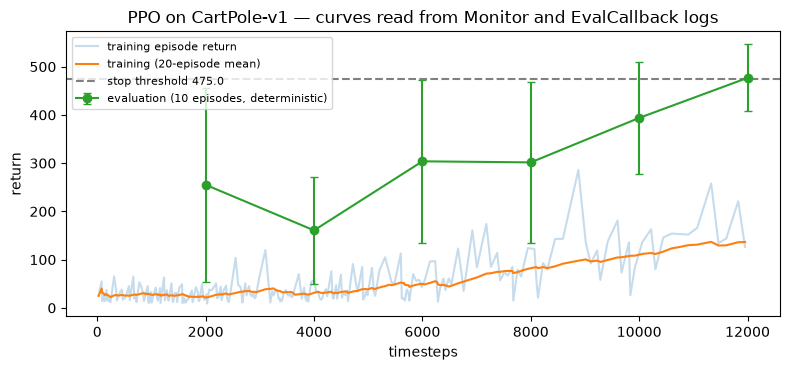

In [20]:
monitor_df = load_results(str(MONITOR_DIR))
monitor_df["timesteps"] = monitor_df["l"].cumsum()
print(monitor_df.head(3).to_string(), "\n...", f"\n{len(monitor_df)} episodes logged")

evaluations = np.load(EVAL_LOG_DIR / "evaluations.npz")
eval_steps, eval_results = evaluations["timesteps"], evaluations["results"]      # results: (n_evals, n_eval_episodes)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(monitor_df["timesteps"], monitor_df["r"], alpha=0.25, label="training episode return")
ax.plot(monitor_df["timesteps"], monitor_df["r"].rolling(20, min_periods=1).mean(), label="training (20-episode mean)")
ax.errorbar(eval_steps, eval_results.mean(axis=1), yerr=eval_results.std(axis=1), fmt="o-", capsize=3, label="evaluation (10 episodes, deterministic)")
ax.axhline(threshold, ls="--", c="gray", label=f"stop threshold {threshold}")
ax.set(xlabel="timesteps", ylabel="return", title="PPO on CartPole-v1 — curves read from Monitor and EvalCallback logs")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Training returns are lower and noisier than evaluation returns because training actions are **sampled** from the stochastic policy, while evaluation uses the most likely action.

> 💡 **Interview angle:** "Your training reward curve looks great — are you done?" — training returns include exploration noise and can be computed on a different env configuration; always confirm with separate deterministic evaluations, several seeds, and look at the variance, not just the mean.

## 11. Vectorized Environments: A Fair Speed Comparison 🟡

A **vectorized environment** steps `n_envs` copies at once, so the policy network runs on a batch of observations instead of one at a time.

- `DummyVecEnv` — all copies in the same process, stepped one after another (no inter-process overhead).
- `SubprocVecEnv` — each copy in its own process (helps only when a single env step is expensive, e.g. physics or rendering).

**A fair comparison** keeps the *learning problem* identical: the same total timesteps, the same rollout size (`n_envs × n_steps`), the same mini-batch size and epochs — so every configuration performs the **same number of gradient updates**. Only then does wall-clock time tell you about the vectorization itself.

In [21]:
TOTAL = 24_576                                               # = 48 rollouts of 512 steps
speed_configs = [("1 env × 512 steps (DummyVecEnv)", 1, 512, DummyVecEnv),
                 ("8 envs × 64 steps (DummyVecEnv)", 8, 64, DummyVecEnv),
                 ("8 envs × 64 steps (SubprocVecEnv)", 8, 64, SubprocVecEnv)]
speed_rows = []
for label, n_envs, n_steps, vec_cls in speed_configs:
    try:
        venv = make_vec_env("CartPole-v1", n_envs=n_envs, seed=0, vec_env_cls=vec_cls)
    except Exception as err:                                  # multiprocessing can be unavailable in some sandboxes
        print(f"⏭️ Skipped {label}: could not start worker processes ({type(err).__name__}: {err})")
        continue
    model = PPO("MlpPolicy", venv, n_steps=n_steps, batch_size=64, n_epochs=10, seed=0, device=DEVICE)
    start = time.perf_counter()
    model.learn(total_timesteps=TOTAL)
    seconds = time.perf_counter() - start
    eval_mean, _ = evaluate_policy(model, eval_env_for("CartPole-v1", 30_000), n_eval_episodes=10)
    speed_rows.append({"configuration": label, "timesteps": model.num_timesteps, "gradient updates": model._n_updates,
                       "seconds": round(seconds, 1), "steps/s": round(model.num_timesteps / seconds), "eval return": eval_mean})
    venv.close()

speed = pd.DataFrame(speed_rows).set_index("configuration")
assert speed["timesteps"].nunique() == 1 and speed["gradient updates"].nunique() == 1, "comparison is not fair"
print("✅ same timesteps and same number of gradient updates in every row\n")
print(speed.to_string())
baseline_seconds = speed["seconds"].iloc[0]
for label, row in speed.iloc[1:].iterrows():
    print(f"{label}: {baseline_seconds / row['seconds']:.2f}× the speed of a single env")

✅ same timesteps and same number of gradient updates in every row

                                   timesteps  gradient updates  seconds  steps/s  eval return
configuration                                                                                
1 env × 512 steps (DummyVecEnv)        24576               480      3.8     6541        500.0
8 envs × 64 steps (DummyVecEnv)        24576               480      2.1    11780        467.1
8 envs × 64 steps (SubprocVecEnv)      24576               480      2.4    10095        467.1
8 envs × 64 steps (DummyVecEnv): 1.81× the speed of a single env
8 envs × 64 steps (SubprocVecEnv): 1.58× the speed of a single env


For CartPole a single step is microseconds, so batching the *policy* is what saves time; subprocesses add communication overhead that the cheap physics can't repay. With an expensive simulator the picture flips. The eval column differs a little because the data arrives in a different order — a reminder that even "the same" run isn't bit-identical across configurations.

> 💡 **Interview angle:** "How would you speed up RL training?" — vectorize environments (and measure: Dummy vs Subproc), keep the learning setup fixed when benchmarking (same timesteps, rollout size, updates), use off-policy methods when env steps are expensive, and profile whether time goes to the simulator or the network.

## 12. Hyperparameters, Devices, and Seeds 🟡

### Key hyperparameters

| Algorithm | Hyperparameter | What it controls | SB3 default |
|---|---|---|---|
| PPO | `n_steps` × `n_envs` | rollout size per update (bigger = less noisy, fewer updates) | 2048 × n_envs |
| PPO | `batch_size`, `n_epochs` | mini-batch size, passes over each rollout | 64, 10 |
| PPO | `clip_range`, `target_kl` | how far one update may move the policy | 0.2, None |
| PPO / A2C | `gamma`, `gae_lambda` | horizon; bias–variance of advantages | 0.99, 0.95 (A2C: 1.0) |
| PPO / A2C | `ent_coef`, `vf_coef`, `max_grad_norm` | exploration bonus, critic weight, gradient clipping | 0.0, 0.5, 0.5 |
| DQN | `buffer_size`, `learning_starts` | replay memory size; random steps before learning | 1,000,000, 100 |
| DQN | `target_update_interval`, `train_freq`, `gradient_steps` | target sync period; how often and how much to train | 10,000, 4, 1 |
| DQN | `exploration_fraction`, `exploration_final_eps` | ε schedule as a fraction of training | 0.1, 0.05 |
| SAC | `tau`, `ent_coef`, `learning_starts` | soft target update, entropy temperature | 0.005, "auto", 100 |

Start from tuned values (the RL Baselines3 Zoo) rather than defaults, change one thing at a time, and tune with several seeds (e.g. with Optuna).

### CPU or GPU? Measure it.

In [22]:
def time_training_step(device, n_iters=300):
    net = nn.Sequential(nn.Linear(4, 64), nn.Tanh(), nn.Linear(64, 64), nn.Tanh(), nn.Linear(64, 2)).to(device)
    opt = torch.optim.Adam(net.parameters())
    x_batch, x_single = torch.randn(64, 4, device=device), torch.randn(1, 4, device=device)
    sync = torch.mps.synchronize if device == "mps" else (lambda: None)
    for _ in range(20):                                        # warm-up
        net(x_batch).sum().backward()
    sync()
    start = time.perf_counter()
    for _ in range(n_iters):
        opt.zero_grad()
        net(x_batch).pow(2).mean().backward()
        opt.step()
    sync()
    train_ms = (time.perf_counter() - start) / n_iters * 1000
    start = time.perf_counter()
    with torch.no_grad():
        for _ in range(n_iters):
            net(x_single).argmax().item()                     # what happens once per environment step
    act_ms = (time.perf_counter() - start) / n_iters * 1000
    return train_ms, act_ms


devices = ["cpu"] + (["mps"] if torch.backends.mps.is_available() else []) + (["cuda"] if torch.cuda.is_available() else [])
device_times = {d: time_training_step(d) for d in devices}
for d, (train_ms, act_ms) in device_times.items():
    print(f"{d:4s}: {train_ms:.3f} ms per mini-batch update | {act_ms:.3f} ms per single action")
if len(device_times) == 1:
    print("⏭️ Only a CPU is available here, so there is nothing to compare against.")
else:
    fastest = min(device_times, key=lambda d: sum(device_times[d]))
    print(f"→ fastest for this small MLP: {fastest} (this is why DEVICE = 'cpu' in Setup)")

cpu : 0.149 ms per mini-batch update | 0.010 ms per single action
mps : 0.615 ms per mini-batch update | 1.469 ms per single action
→ fastest for this small MLP: cpu (this is why DEVICE = 'cpu' in Setup)


### Seeds and variance

RL training is a random process: the seed changes network initialisation, exploration, and environment randomness. Let's train the **same** algorithm with the **same** hyperparameters on 5 seeds.

In [23]:
seed_rows = []
start = time.perf_counter()
for seed in range(5):
    model = A2C("MlpPolicy", make_vec_env("CartPole-v1", n_envs=8, seed=seed), seed=seed, device=DEVICE)
    model.learn(total_timesteps=30_000)
    mean, std = evaluate_policy(model, eval_env_for("CartPole-v1", 40_000 + seed), n_eval_episodes=20)
    seed_rows.append({"seed": seed, "eval mean": mean, "eval std": std})
seeds_df = pd.DataFrame(seed_rows)
print(seeds_df.round(1).to_string(index=False))
print(f"\nA2C, 30k steps, 5 seeds: {seeds_df['eval mean'].mean():.1f} ± {seeds_df['eval mean'].std(ddof=1):.1f} "
      f"(best seed {seeds_df['eval mean'].max():.0f}, worst {seeds_df['eval mean'].min():.0f}) — {time.perf_counter() - start:.0f} s")
print(f"Reporting only the best seed would overstate the result by {seeds_df['eval mean'].max() - seeds_df['eval mean'].mean():.0f} return points.")

 seed  eval mean  eval std
    0      362.8      66.0
    1      319.4     114.6
    2      456.4      59.7
    3      355.4     113.3
    4      208.0      21.8

A2C, 30k steps, 5 seeds: 340.4 ± 89.7 (best seed 456, worst 208) — 7 s
Reporting only the best seed would overstate the result by 116 return points.


> 💡 **Interview angle:** "Why do RL papers need multiple seeds?" — results vary a lot between seeds with identical code (Henderson et al., *Deep RL That Matters*); report mean ± std or confidence intervals over ≥ 3–10 seeds, and never pick the best seed after the fact.

## 13. From Games to LLMs: RLHF, DPO, and GRPO 🟡

An LLM generating an answer *is* an RL agent: the **state** is the prompt plus the tokens so far, each **action** is the next token, and the **episode** ends at the end-of-sequence token. The question is where the **reward** comes from.

### RLHF (InstructGPT, Ouyang et al. 2022)
1. **SFT** — fine-tune the base model on human-written demonstrations.
2. **Reward model** — humans compare two answers; train a model $r_\phi(x, y)$ with the Bradley–Terry loss $-\log \sigma\big(r_\phi(x, y_\text{chosen}) - r_\phi(x, y_\text{rejected})\big)$.
3. **PPO** — optimise the policy to maximise $r_\phi(x, y) - \beta\, \text{KL}\big(\pi_\theta(\cdot \mid x)\,\|\,\pi_\text{ref}(\cdot \mid x)\big)$. The KL penalty keeps it close to the SFT model so it doesn't **reward-hack** the imperfect reward model. PPO needs four models in memory: policy, reference, reward model, and value (critic).

### DPO (Rafailov et al. 2023)
The KL-regularised objective has a closed-form optimal policy, which implies the reward can be written as $\beta \log \frac{\pi_\theta(y \mid x)}{\pi_\text{ref}(y \mid x)}$ (plus a term that cancels in comparisons). Plugging that into the Bradley–Terry loss gives a plain classification loss on preference pairs:

$$L_\text{DPO} = -\log \sigma\Big(\beta\Big[\log\frac{\pi_\theta(y_w \mid x)}{\pi_\text{ref}(y_w \mid x)} - \log\frac{\pi_\theta(y_l \mid x)}{\pi_\text{ref}(y_l \mid x)}\Big]\Big)$$

No separate reward model, no sampling during training, no critic — just two models (policy + frozen reference) and supervised-style training.

### GRPO (DeepSeekMath, Shao et al. 2024)
Keep the PPO-style clipped objective and KL penalty, but **drop the critic**: sample a **group** of $G$ answers per prompt, score them (often with a *verifiable* reward like "is the maths answer correct?"), and use the group-normalised reward as every token's advantage: $\hat A_i = \frac{r_i - \text{mean}(r)}{\text{std}(r)}$. This saves the memory of a value network and works well for reasoning tasks.

The numbers below are **toy values** (no LLM involved) that show exactly what each loss computes. You'll train with DPO for real in [Fine-Tuning with LoRA and DPO](../08_Generative_AI_LLM/07_Fine_Tuning_LoRA_and_DPO.ipynb).

In [24]:
# 1) Reward model: Bradley–Terry loss on 3 preference pairs (toy reward scores)
r_chosen, r_rejected = torch.tensor([2.0, 0.5, 1.0]), torch.tensor([1.0, 1.5, 1.0])
bt_loss = -F.logsigmoid(r_chosen - r_rejected)
print("Bradley–Terry loss per pair:", bt_loss.numpy().round(3), "← small when the chosen answer already scores higher")

# 2) DPO loss from sequence log-probabilities under the policy and the frozen reference model
def dpo_loss(policy_chosen, policy_rejected, ref_chosen, ref_rejected, beta=0.1):
    margin = (policy_chosen - ref_chosen) - (policy_rejected - ref_rejected)
    return -F.logsigmoid(beta * margin).mean()


print(f"DPO loss, policy == reference            : {dpo_loss(torch.tensor([-12.0]), torch.tensor([-15.0]), torch.tensor([-12.0]), torch.tensor([-15.0])):.4f}  (= log 2)")
print(f"DPO loss, policy now prefers chosen more : {dpo_loss(torch.tensor([-10.0]), torch.tensor([-17.0]), torch.tensor([-12.0]), torch.tensor([-15.0])):.4f}")

# 3) GRPO: group-relative advantages for 6 sampled answers to one prompt (1 = correct, 0 = wrong)
group_rewards = np.array([1.0, 0.0, 0.0, 1.0, 1.0, 0.0])
grpo_advantages = (group_rewards - group_rewards.mean()) / (group_rewards.std() + 1e-8)
print("GRPO advantages:", grpo_advantages.round(3), "← correct answers pushed up, wrong ones down, no critic needed")

Bradley–Terry loss per pair: [0.313 1.313 0.693] ← small when the chosen answer already scores higher
DPO loss, policy == reference            : 0.6931  (= log 2)
DPO loss, policy now prefers chosen more : 0.5130
GRPO advantages: [ 1. -1. -1.  1.  1. -1.] ← correct answers pushed up, wrong ones down, no critic needed


### ✍️ Your Turn

Four sampled answers to one prompt get rewards `[1, 0, 0, 1]`. Compute the GRPO advantages using the **population** std (`np.std`, no epsilon). Store them in `my_grpo_adv`.

In [25]:
my_grpo_adv = None  # TODO: your code here
check("my_grpo_adv", my_grpo_adv, [1.0, -1.0, -1.0, 1.0], hint="(r − r.mean()) / r.std()")

⏳ my_grpo_adv: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
r = np.array([1.0, 0.0, 0.0, 1.0])
my_grpo_adv = (r - r.mean()) / r.std()            # mean 0.5, std 0.5
check("my_grpo_adv", my_grpo_adv, [1.0, -1.0, -1.0, 1.0])
```
If all answers in a group get the same reward, the advantages are all zero — that prompt teaches nothing, which is why GRPO pipelines filter prompts that are too easy or too hard.
</details>

> 💡 **Interview angle:** "RLHF vs DPO vs GRPO?" — RLHF trains a reward model then runs PPO with a KL penalty (4 models, online sampling, finicky). DPO turns preference data directly into a classification-style loss using the policy/reference log-ratio as an implicit reward (no reward model, no RL loop, offline). GRPO keeps online RL but replaces the critic with group-normalised rewards — popular for reasoning with verifiable rewards.

## 🔧 Build It From Scratch

**Goal:** implement **REINFORCE with a learned value baseline** in plain PyTorch on CartPole — then put its real learning curve next to SB3's PPO on the **same environment, seeds, and timestep budget**.

First, a check against the library: our discounted reward-to-go must equal SB3's `RolloutBuffer` returns when GAE uses $\lambda = 1$ and all value estimates are zero (that's exactly the Monte Carlo return).

In [26]:
def reward_to_go(rewards, gamma, bootstrap_value=0.0):
    """G_t = r_t + γ r_{t+1} + ... (+ γ^k · V(s_last) if the episode was truncated)."""
    returns, running = np.zeros(len(rewards)), bootstrap_value
    for t in reversed(range(len(rewards))):
        running = rewards[t] + gamma * running
        returns[t] = running
    return returns


episode_rewards = np.array([1.0, 0.5, -0.2, 2.0, 1.0])
mc_buffer = RolloutBuffer(5, gym.spaces.Box(-1, 1, (2,)), gym.spaces.Discrete(2), device="cpu", gamma=0.97, gae_lambda=1.0, n_envs=1)
for t in range(5):
    mc_buffer.add(np.zeros((1, 2), dtype=np.float32), np.zeros((1, 1)), np.array([episode_rewards[t]], dtype=np.float32),
                  np.array([float(t == 0)]), torch.zeros(1), torch.zeros(1))
mc_buffer.compute_returns_and_advantage(torch.zeros(1), np.array([True]))
assert np.allclose(reward_to_go(episode_rewards, 0.97), mc_buffer.returns.ravel(), atol=1e-5)
print("✅ reward-to-go matches SB3's Monte Carlo returns:", reward_to_go(episode_rewards, 0.97).round(4))

✅ reward-to-go matches SB3's Monte Carlo returns: [4.008 3.1   2.681 2.97  1.   ]


In [27]:
def reinforce_with_baseline(env_id, total_timesteps, seed, gamma=0.99, lr=3e-3, hidden=64):
    """Monte Carlo policy gradient with a learned V(s) baseline. Returns [(cumulative timesteps, episode return), ...]."""
    torch.manual_seed(seed)
    env = gym.make(env_id)
    obs_dim, n_actions = env.observation_space.shape[0], env.action_space.n
    policy = nn.Sequential(nn.Linear(obs_dim, hidden), nn.Tanh(), nn.Linear(hidden, n_actions))
    value = nn.Sequential(nn.Linear(obs_dim, hidden), nn.Tanh(), nn.Linear(hidden, 1))
    optimizer = torch.optim.Adam(list(policy.parameters()) + list(value.parameters()), lr=lr)

    history, timesteps = [], 0
    obs, _ = env.reset(seed=seed)
    while timesteps < total_timesteps:
        observations, actions, rewards = [], [], []
        done = False
        while not done:                                                       # 1) play one episode
            obs_t = torch.as_tensor(obs, dtype=torch.float32)
            with torch.no_grad():
                action = torch.distributions.Categorical(logits=policy(obs_t)).sample().item()
            obs, reward, terminated, truncated, _ = env.step(action)
            observations.append(obs_t)
            actions.append(action)
            rewards.append(reward)
            done = terminated or truncated
        timesteps += len(rewards)
        history.append((timesteps, sum(rewards)))

        bootstrap = 0.0
        if truncated and not terminated:                                      # time limit: the future still has value
            with torch.no_grad():
                bootstrap = value(torch.as_tensor(obs, dtype=torch.float32)).item()
        returns = torch.as_tensor(reward_to_go(rewards, gamma, bootstrap), dtype=torch.float32)   # 2) reward-to-go

        states = torch.stack(observations)
        log_probs = torch.distributions.Categorical(logits=policy(states)).log_prob(torch.as_tensor(actions))
        values = value(states).squeeze(-1)
        advantages = returns - values.detach()                                # 3) subtract the baseline
        if len(advantages) > 1:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        policy_loss = -(log_probs * advantages).mean()                        # 4) policy gradient
        value_loss = F.mse_loss(values, returns)                              # 5) fit the baseline
        optimizer.zero_grad()
        (policy_loss + 0.5 * value_loss).backward()
        optimizer.step()
        obs, _ = env.reset()
    env.close()
    return np.array(history)


BUILD_SEEDS, BUILD_STEPS = [0, 1, 2], 60_000
start = time.perf_counter()
reinforce_runs = {seed: reinforce_with_baseline("CartPole-v1", BUILD_STEPS, seed) for seed in BUILD_SEEDS}
print(f"REINFORCE: {len(BUILD_SEEDS)} seeds × {BUILD_STEPS:,} steps in {time.perf_counter() - start:.0f} s")

start = time.perf_counter()
ppo_runs = {}
for seed in BUILD_SEEDS:
    run_dir = fresh_dir(f"build_ppo_seed{seed}")
    env = make_vec_env("CartPole-v1", n_envs=1, seed=seed, monitor_dir=str(run_dir))
    PPO("MlpPolicy", env, seed=seed, device=DEVICE).learn(total_timesteps=BUILD_STEPS)
    env.close()
    log = load_results(str(run_dir))
    ppo_runs[seed] = np.column_stack([log["l"].cumsum(), log["r"]])
print(f"SB3 PPO  : {len(BUILD_SEEDS)} seeds × {BUILD_STEPS:,} steps in {time.perf_counter() - start:.0f} s")

REINFORCE: 3 seeds × 60,000 steps in 6 s


SB3 PPO  : 3 seeds × 60,000 steps in 26 s


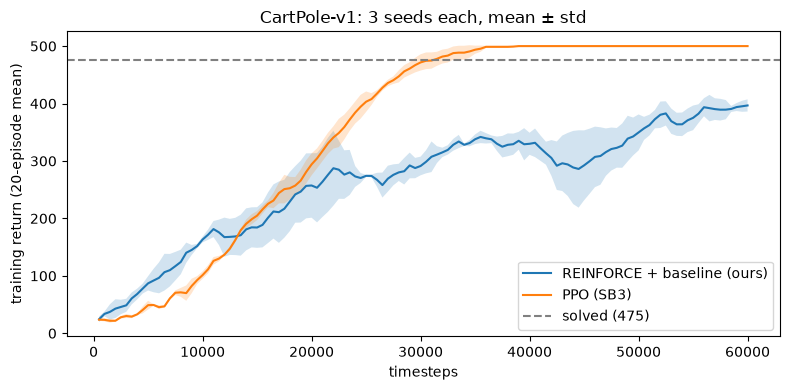

                             last-20-episode return (mean over seeds)  std over seeds  seeds reaching a 20-ep mean of 475  timesteps to 475 (mean of seeds that did)
REINFORCE + baseline (ours)                                     397.0            13.1                                 0.0                                        NaN
PPO (SB3)                                                       500.0             0.0                                 3.0                                    32066.0

✅ our REINFORCE learns (final 397 vs random ≈ 22). PPO ends higher (500 vs 397) on the same budget.


In [28]:
GRID = np.linspace(0, BUILD_STEPS, 121)


def curve_on_grid(history, window=20):
    """Rolling mean of episode returns, interpolated onto a common timestep grid (NaN before the first episode ends)."""
    steps, rets = history[:, 0], pd.Series(history[:, 1]).rolling(window, min_periods=1).mean().to_numpy()
    return np.where(GRID >= steps[0], np.interp(GRID, steps, rets), np.nan)


fig, ax = plt.subplots(figsize=(8, 4))
build_summary = {}
for name, runs_ in [("REINFORCE + baseline (ours)", reinforce_runs), ("PPO (SB3)", ppo_runs)]:
    curves = np.stack([curve_on_grid(h) for h in runs_.values()])
    has_data = ~np.all(np.isnan(curves), axis=0)                       # skip grid points before any episode finished
    mean, std = np.nanmean(curves[:, has_data], axis=0), np.nanstd(curves[:, has_data], axis=0)
    ax.plot(GRID[has_data], mean, label=name)
    ax.fill_between(GRID[has_data], mean - std, mean + std, alpha=0.2)
    final = np.array([h[-20:, 1].mean() for h in runs_.values()])
    reached = [h[np.argmax(pd.Series(h[:, 1]).rolling(20).mean().to_numpy() >= 475), 0]
               if (pd.Series(h[:, 1]).rolling(20).mean() >= 475).any() else np.nan for h in runs_.values()]
    build_summary[name] = {"last-20-episode return (mean over seeds)": final.mean(), "std over seeds": final.std(ddof=1),
                           "seeds reaching a 20-ep mean of 475": int(np.sum(~np.isnan(reached))),
                           "timesteps to 475 (mean of seeds that did)": np.nanmean(reached) if np.any(~np.isnan(reached)) else np.nan}
ax.axhline(475, ls="--", c="gray", label="solved (475)")
ax.set(xlabel="timesteps", ylabel="training return (20-episode mean)", title="CartPole-v1: 3 seeds each, mean ± std")
ax.legend()
plt.tight_layout()
plt.show()

build_table = pd.DataFrame(build_summary).T.round(1)
print(build_table.to_string())
ours = build_table.loc["REINFORCE + baseline (ours)", "last-20-episode return (mean over seeds)"]
theirs = build_table.loc["PPO (SB3)", "last-20-episode return (mean over seeds)"]
assert ours > 150, "REINFORCE should learn well beyond a random policy (~22)"
print(f"\n✅ our REINFORCE learns (final {ours:.0f} vs random ≈ 22). "
      f"{'PPO' if theirs > ours else 'REINFORCE'} ends higher ({max(ours, theirs):.0f} vs {min(ours, theirs):.0f}) on the same budget.")

PPO typically wins because it reuses every rollout for 10 epochs of mini-batch updates, uses GAE instead of full Monte Carlo returns, and clips updates so a lucky or unlucky episode can't wreck the policy. REINFORCE throws each episode away after a single gradient step.

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Creating a callback but never passing it to `learn`

Nothing warns you: training simply runs the full budget.

In [29]:
def a2c_with_stop_callback(pass_callback, budget=40_000, reward_threshold=150):
    venv = make_vec_env("CartPole-v1", n_envs=8, seed=0)
    stop = StopTrainingOnRewardThreshold(reward_threshold=reward_threshold, verbose=0)
    evaluator = EvalCallback(eval_env_for("CartPole-v1", 50_000), callback_on_new_best=stop,
                             eval_freq=max(2_000 // venv.num_envs, 1), n_eval_episodes=5, verbose=0)
    model = A2C("MlpPolicy", venv, seed=0, device=DEVICE)
    start = time.perf_counter()
    model.learn(total_timesteps=budget, callback=evaluator if pass_callback else None)
    return model.num_timesteps, time.perf_counter() - start


steps_wrong, secs_wrong = a2c_with_stop_callback(pass_callback=False)
steps_right, secs_right = a2c_with_stop_callback(pass_callback=True)
print(f"❌ callback created, not passed: trained {steps_wrong:,} steps ({secs_wrong:.1f} s)")
print(f"✅ callback passed to learn()  : trained {steps_right:,} steps ({secs_right:.1f} s)"
      + (" — stopped early" if steps_right < steps_wrong else " — threshold not reached, so no early stop"))

❌ callback created, not passed: trained 40,000 steps (1.1 s)
✅ callback passed to learn()  : trained 8,000 steps (0.4 s) — stopped early


### ❌ Pitfall 2 — Treating `eval_freq` as timesteps with several environments

`eval_freq` counts **callback calls**, and each call is `n_envs` timesteps. With 8 envs, `eval_freq=2000` evaluates every 16,000 timesteps.

In [30]:
def count_evaluations(eval_freq, n_envs=8, budget=16_000):
    log_dir = fresh_dir(f"eval_freq_{eval_freq}")
    evaluator = EvalCallback(eval_env_for("CartPole-v1", 60_000), eval_freq=eval_freq, n_eval_episodes=2,
                             log_path=str(log_dir), verbose=0)
    A2C("MlpPolicy", make_vec_env("CartPole-v1", n_envs=n_envs, seed=0), seed=0, device=DEVICE).learn(budget, callback=evaluator)
    return evaluator.evaluations_timesteps


print("❌ eval_freq=2000 with 8 envs → evaluations at timesteps", count_evaluations(2000), "(wanted one every 2,000)")
print("✅ eval_freq=2000 // 8        → evaluations at timesteps", count_evaluations(2000 // 8))

❌ eval_freq=2000 with 8 envs → evaluations at timesteps [16000] (wanted one every 2,000)


✅ eval_freq=2000 // 8        → evaluations at timesteps [2000, 4000, 6000, 8000, 10000, 12000, 14000, 16000]


### ❌ Pitfall 3 — An unfair vectorized-env benchmark

Keeping PPO's default `n_steps=2048` *per env* while going from 1 to 8 envs multiplies the rollout to 16,384 steps. For a 20,000-step budget SB3 finishes the rollout it started, so the run uses **more** environment steps and **far fewer** gradient updates — "faster per step" but a worse agent. (Section 11 shows the fair version.)

In [31]:
unfair_rows = []
for label, n_envs in [("❌ 8 envs × default n_steps=2048", 8), ("✅ 1 env × default n_steps=2048", 1)]:
    model = PPO("MlpPolicy", make_vec_env("CartPole-v1", n_envs=n_envs, seed=0), seed=0, device=DEVICE)
    start = time.perf_counter()
    model.learn(total_timesteps=20_000)
    seconds = time.perf_counter() - start
    mean, _ = evaluate_policy(model, eval_env_for("CartPole-v1", 70_000), n_eval_episodes=10)
    unfair_rows.append({"run": label, "requested": 20_000, "timesteps actually used": model.num_timesteps,
                        "gradient updates": model._n_updates, "seconds": round(seconds, 1), "eval return": mean})
print(pd.DataFrame(unfair_rows).set_index("run").to_string())

                                 requested  timesteps actually used  gradient updates  seconds  eval return
run                                                                                                        
❌ 8 envs × default n_steps=2048      20000                    32768                20      2.8        294.3
✅ 1 env × default n_steps=2048       20000                    20480               100      2.9        500.0


### ❌ Pitfall 4 — Evaluating with a stochastic policy (or too few episodes)

`evaluate_policy` defaults to `deterministic=True`, but custom evaluation loops often sample actions — and a couple of episodes can say anything. We use the A2C agent from Section 5, which is good but not perfect.

In [32]:
stoch_mean, stoch_std = evaluate_policy(a2c_model, eval_env_for("CartPole-v1", 80_000), n_eval_episodes=50, deterministic=False)
few_rewards, _ = evaluate_policy(a2c_model, eval_env_for("CartPole-v1", 81_000), n_eval_episodes=2, deterministic=False, return_episode_rewards=True)
det_mean, det_std = evaluate_policy(a2c_model, eval_env_for("CartPole-v1", 80_000), n_eval_episodes=50, deterministic=True)
print(f"❌ sampled actions, 2 episodes : {np.mean(few_rewards):.1f} (episodes: {few_rewards})")
print(f"❌ sampled actions, 50 episodes: {stoch_mean:.1f} ± {stoch_std:.1f}")
print(f"✅ deterministic, 50 episodes  : {det_mean:.1f} ± {det_std:.1f}")
print(f"→ the evaluation protocol alone moves the reported number by {abs(det_mean - stoch_mean):.1f} (sampling vs deterministic) "
      f"and by {abs(det_mean - np.mean(few_rewards)):.1f} (2 sampled episodes vs 50 deterministic)")

❌ sampled actions, 2 episodes : 445.0 (episodes: [390.0, 500.0])
❌ sampled actions, 50 episodes: 331.5 ± 68.3
✅ deterministic, 50 episodes  : 373.7 ± 55.4
→ the evaluation protocol alone moves the reported number by 42.2 (sampling vs deterministic) and by 71.3 (2 sampled episodes vs 50 deterministic)


### ❌ Pitfall 5 — Treating a time-out as the end of the world in your own code

In your own policy-gradient code, cutting the return at a time limit teaches the critic that late states are worth nothing. The REINFORCE above bootstraps with `V(s_last)` on truncation. Here's the size of the difference for a CartPole episode that hits the 500-step limit, with a critic that (correctly) estimates the remaining value at about $1/(1-\gamma) = 100$:

In [33]:
rewards_500 = np.ones(500)
g_wrong = reward_to_go(rewards_500, gamma=0.99)                     # ❌ treats step 500 as terminal
g_right = reward_to_go(rewards_500, gamma=0.99, bootstrap_value=100.0)  # ✅ bootstraps on truncation
for t in [0, 400, 490, 499]:
    print(f"t={t:3d}: ❌ target {g_wrong[t]:6.2f} | ✅ target {g_right[t]:6.2f}")
print("The ❌ targets fall towards 1 near the time limit, although those states look exactly like early ones.")

t=  0: ❌ target  99.34 | ✅ target 100.00
t=400: ❌ target  63.40 | ✅ target 100.00
t=490: ❌ target   9.56 | ✅ target 100.00
t=499: ❌ target   1.00 | ✅ target 100.00
The ❌ targets fall towards 1 near the time limit, although those states look exactly like early ones.


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Count the parameters of a Q-network
How many trainable parameters does an MLP `4 → 64 → 64 → 2` (with biases) have?

In [34]:
q_net_params = None  # TODO
check("q_net_params", q_net_params, 4610, hint="Each Linear(i, o) has i·o weights + o biases.")

⏳ q_net_params: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
q_net_params = (4 * 64 + 64) + (64 * 64 + 64) + (64 * 2 + 2)
check("q_net_params", q_net_params, 4610)

# or let PyTorch count
net = nn.Sequential(nn.Linear(4, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 2))
check("q_net_params (torch)", sum(p.numel() for p in net.parameters()), 4610)
```
</details>

### 🟢 Exercise 2 — DQN targets for a batch
`next_q_target[i]` holds the target network's Q-values for the next state of transition `i`. With $\gamma = 0.9$, compute the DQN targets (no bootstrap on terminated transitions).

In [35]:
batch_rewards = torch.tensor([1.0, 1.0, 1.0])
next_q_target = torch.tensor([[1.0, 2.0], [3.0, 0.0], [5.0, 5.0]])
batch_terminated = torch.tensor([0.0, 1.0, 0.0])
dqn_targets = None  # TODO
check("dqn_targets", dqn_targets, [2.8, 1.0, 5.5], hint="r + γ · (1 − terminated) · next_q_target.max(dim=1).values")

⏳ dqn_targets: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
batch_rewards = torch.tensor([1.0, 1.0, 1.0])
next_q_target = torch.tensor([[1.0, 2.0], [3.0, 0.0], [5.0, 5.0]])
batch_terminated = torch.tensor([0.0, 1.0, 0.0])
dqn_targets = batch_rewards + 0.9 * (1 - batch_terminated) * next_q_target.max(dim=1).values
check("dqn_targets", dqn_targets, [2.8, 1.0, 5.5])
```
</details>

### 🟢 Exercise 3 — How many gradient updates does PPO do?
PPO with `n_envs=8`, `n_steps=128`, `batch_size=256`, `n_epochs=4`, trained for `total_timesteps=51_200`. How many mini-batch gradient updates happen?

In [36]:
ppo_updates = None  # TODO
check("ppo_updates", ppo_updates, 800, hint="rollouts = total / (n_envs·n_steps); minibatches per epoch = rollout size / batch_size.")

⏳ ppo_updates: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
rollout_size = 8 * 128                     # 1,024 steps per rollout
n_rollouts = 51_200 // rollout_size        # 50
minibatches = rollout_size // 256          # 4 per epoch
ppo_updates = n_rollouts * 4 * minibatches # epochs × minibatches × rollouts
check("ppo_updates", ppo_updates, 800)
```
This arithmetic is how you reason about sample efficiency and fair comparisons (Pitfall 3).
</details>

### 🟡 Exercise 4 — PPO clipped objective on a mini-batch
With `clip_range=0.2`, compute the **mean** clipped surrogate objective for the four samples below. Use PyTorch (no helper functions).

In [37]:
batch_ratio = torch.tensor([0.7, 1.0, 1.4, 1.4])
batch_adv = torch.tensor([1.0, 1.0, 1.0, -1.0])
clipped_objective = None  # TODO
check("clipped_objective", clipped_objective, 0.375, hint="torch.min(r·A, torch.clamp(r, 0.8, 1.2)·A).mean()")

⏳ clipped_objective: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
batch_ratio = torch.tensor([0.7, 1.0, 1.4, 1.4])
batch_adv = torch.tensor([1.0, 1.0, 1.0, -1.0])
surrogate_1 = batch_ratio * batch_adv
surrogate_2 = torch.clamp(batch_ratio, 0.8, 1.2) * batch_adv
clipped_objective = torch.min(surrogate_1, surrogate_2).mean()     # (0.7 + 1.0 + 1.2 − 1.4) / 4
check("clipped_objective", clipped_objective, 0.375)
```
The loss you minimise is `-clipped_objective`. Note the last sample: the ratio rose on a bad action, so PPO keeps the *unclipped* −1.4 — the pessimistic choice — and still pushes it back down.
</details>

### 🟡 Exercise 5 — GAE by hand
One rollout of 3 steps, no episode ends, bootstrap value after the last step `0.2`, $\gamma = 0.9$, $\lambda = 0.8$. Compute the GAE advantages.

In [38]:
gae_rewards = np.array([1.0, 1.0, 1.0])
gae_values = np.array([0.5, 0.4, 0.3])
gae_advantages = None  # TODO
check("gae_advantages", gae_advantages, [1.942592, 1.5036, 0.88], hint="δ_t = r_t + γV(s_{t+1}) − V(s_t); A_t = δ_t + γλ·A_{t+1}, backwards.")

⏳ gae_advantages: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
gae_rewards = np.array([1.0, 1.0, 1.0])
gae_values = np.array([0.5, 0.4, 0.3])
gamma, lam = 0.9, 0.8
next_values = np.append(gae_values[1:], 0.2)                   # bootstrap after the last step
deltas = gae_rewards + gamma * next_values - gae_values        # [0.86, 0.87, 0.88]
gae_advantages, running = np.zeros(3), 0.0
for t in reversed(range(3)):
    running = deltas[t] + gamma * lam * running
    gae_advantages[t] = running
check("gae_advantages", gae_advantages, [1.942592, 1.5036, 0.88])
```
</details>

### 🔴 Exercise 6 — Implement the DPO loss (interview classic)
Given sequence log-probabilities for 2 preference pairs under the **policy** and the frozen **reference** model, compute the mean DPO loss with $\beta = 0.1$ — **write it yourself** with `F.logsigmoid` (don't reuse `dpo_loss` from Section 13).

In [39]:
pol_chosen, pol_rejected = torch.tensor([-10.0, -12.0]), torch.tensor([-11.0, -11.0])
ref_chosen, ref_rejected = torch.tensor([-10.5, -12.0]), torch.tensor([-10.5, -12.0])
my_dpo_loss = None  # TODO
check("my_dpo_loss", my_dpo_loss, 0.694397, hint="margin = (pol_c − ref_c) − (pol_r − ref_r); loss = −logsigmoid(β·margin).mean()")

⏳ my_dpo_loss: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
pol_chosen, pol_rejected = torch.tensor([-10.0, -12.0]), torch.tensor([-11.0, -11.0])
ref_chosen, ref_rejected = torch.tensor([-10.5, -12.0]), torch.tensor([-10.5, -12.0])
beta = 0.1
chosen_logratio = pol_chosen - ref_chosen          # [0.5, 0.0]
rejected_logratio = pol_rejected - ref_rejected    # [-0.5, 1.0]
margin = chosen_logratio - rejected_logratio       # [1.0, -1.0]
my_dpo_loss = -F.logsigmoid(beta * margin).mean()  # mean(0.6444, 0.7444)
check("my_dpo_loss", my_dpo_loss, 0.694397)
```

Pair 1 already moved the right way (loss below log 2 ≈ 0.693); pair 2 made the *rejected* answer more likely, so its loss is above log 2 and its gradient pushes back. `β · logratio` is DPO's *implicit reward*; the reference model keeps the policy from drifting — the same job the KL penalty does in RLHF.
</details>

## 🚀 Mini Project: PPO vs DQN vs A2C on Two Control Tasks

**Goal:** compare three algorithm families — on-policy with clipping (**PPO**), on-policy actor–critic (**A2C**), and off-policy value-based (**DQN**) — on two classic-control tasks, **3 seeds each**, with real learning curves from Monitor logs, a final evaluation table (mean ± std across seeds), and conclusions computed from the numbers.

| Environment | Task | Reward | "Solved" threshold |
|---|---|---|---|
| **CartPole-v1** | balance a pole | +1 per step, max 500 | 475 |
| **Acrobot-v1** | swing a two-link arm above a line | −1 per step until success, episodes capped at 500 | −100 |

**Setup decisions (so the comparison is honest):**
- Same **timestep budget** for every run (50,000) — sample efficiency is part of the comparison.
- Hyperparameters adapted from the **RL Baselines3 Zoo** for each algorithm/env (not tuned on our evaluation seeds). For DQN on Acrobot we use `gradient_steps=2` instead of the Zoo's `-1` to fit the laptop time budget — a disclosed deviation.
- Final evaluation on **separate evaluation seeds**, 20 deterministic episodes per trained agent.
- Total runtime is a few minutes; it scales linearly with seeds and budget.

### Step 1 — Configure the experiment

In [40]:
PROJECT_TIMESTEPS = 50_000
PROJECT_SEEDS = [0, 1, 2]
THRESHOLDS = {"CartPole-v1": 475, "Acrobot-v1": -100}
ALGORITHMS = {"PPO": PPO, "A2C": A2C, "DQN": DQN}
PROJECT_CONFIGS = {
    ("CartPole-v1", "PPO"): dict(n_envs=8, kwargs=dict(n_steps=32, batch_size=256, gae_lambda=0.8, gamma=0.98, n_epochs=20,
                                                       ent_coef=0.0, learning_rate=1e-3)),
    ("CartPole-v1", "A2C"): dict(n_envs=8, kwargs=dict(ent_coef=0.0)),
    ("CartPole-v1", "DQN"): dict(n_envs=1, kwargs=DQN_CARTPOLE),
    ("Acrobot-v1", "PPO"): dict(n_envs=8, kwargs=dict(n_steps=128, gae_lambda=0.94, gamma=0.99, n_epochs=4, ent_coef=0.0)),
    ("Acrobot-v1", "A2C"): dict(n_envs=8, kwargs=dict(ent_coef=0.0)),
    ("Acrobot-v1", "DQN"): dict(n_envs=1, kwargs=dict(learning_rate=6.3e-4, batch_size=128, buffer_size=50_000, learning_starts=0,
                                                      gamma=0.99, target_update_interval=250, train_freq=4, gradient_steps=2,
                                                      exploration_fraction=0.12, exploration_final_eps=0.1,
                                                      policy_kwargs=dict(net_arch=[256, 256]))),
}
print(f"{len(PROJECT_CONFIGS)} (env, algorithm) pairs × {len(PROJECT_SEEDS)} seeds × {PROJECT_TIMESTEPS:,} steps "
      f"= {len(PROJECT_CONFIGS) * len(PROJECT_SEEDS)} training runs")

6 (env, algorithm) pairs × 3 seeds × 50,000 steps = 18 training runs


### Step 2 — Train every (environment, algorithm, seed) and log everything

In [41]:
project_rows, project_logs = [], {}
project_start = time.perf_counter()
for (env_id, algo_name), config in PROJECT_CONFIGS.items():
    for seed in PROJECT_SEEDS:
        run_dir = fresh_dir(f"project/{env_id}_{algo_name}_seed{seed}")
        train_env = make_vec_env(env_id, n_envs=config["n_envs"], seed=seed, monitor_dir=str(run_dir))
        model = ALGORITHMS[algo_name]("MlpPolicy", train_env, seed=seed, device=DEVICE, **config["kwargs"])
        start = time.perf_counter()
        model.learn(total_timesteps=PROJECT_TIMESTEPS)
        seconds = time.perf_counter() - start
        eval_mean, eval_std = evaluate_policy(model, eval_env_for(env_id, 100_000 + seed), n_eval_episodes=20)
        train_env.close()
        log = load_results(str(run_dir))                        # merges the per-env Monitor files, sorted by time
        project_logs[(env_id, algo_name, seed)] = np.column_stack([log["l"].cumsum(), log["r"]])
        project_rows.append({"env": env_id, "algorithm": algo_name, "seed": seed, "eval_mean": eval_mean, "eval_std": eval_std,
                             "train_seconds": seconds, "timesteps": model.num_timesteps, "episodes": len(log)})
        print(f"{env_id:12s} {algo_name}  seed {seed}: eval {eval_mean:7.1f} ± {eval_std:5.1f} | {seconds:5.1f} s | {len(log)} episodes")
project = pd.DataFrame(project_rows)
print(f"\nall runs finished in {time.perf_counter() - project_start:.0f} s")

CartPole-v1  PPO  seed 0: eval   500.0 ±   0.0 |   3.0 s | 301 episodes


CartPole-v1  PPO  seed 1: eval   500.0 ±   0.0 |   3.0 s | 250 episodes


CartPole-v1  PPO  seed 2: eval   500.0 ±   0.0 |   3.0 s | 235 episodes


CartPole-v1  A2C  seed 0: eval   500.0 ±   0.0 |   1.3 s | 411 episodes


CartPole-v1  A2C  seed 1: eval   161.7 ±  13.3 |   1.3 s | 386 episodes


...

Acrobot-v1   A2C  seed 1: eval   -82.8 ±  16.9 |   2.0 s | 441 episodes


Acrobot-v1   A2C  seed 2: eval   -88.8 ±  22.8 |   2.0 s | 400 episodes


Acrobot-v1   DQN  seed 0: eval   -78.8 ±  10.4 |  15.0 s | 392 episodes


Acrobot-v1   DQN  seed 1: eval   -86.6 ±  17.2 |  14.7 s | 307 episodes


Acrobot-v1   DQN  seed 2: eval   -77.7 ±   9.7 |  19.6 s | 348 episodes

all runs finished in 113 s


### Step 3 — Learning curves (mean ± std across seeds)

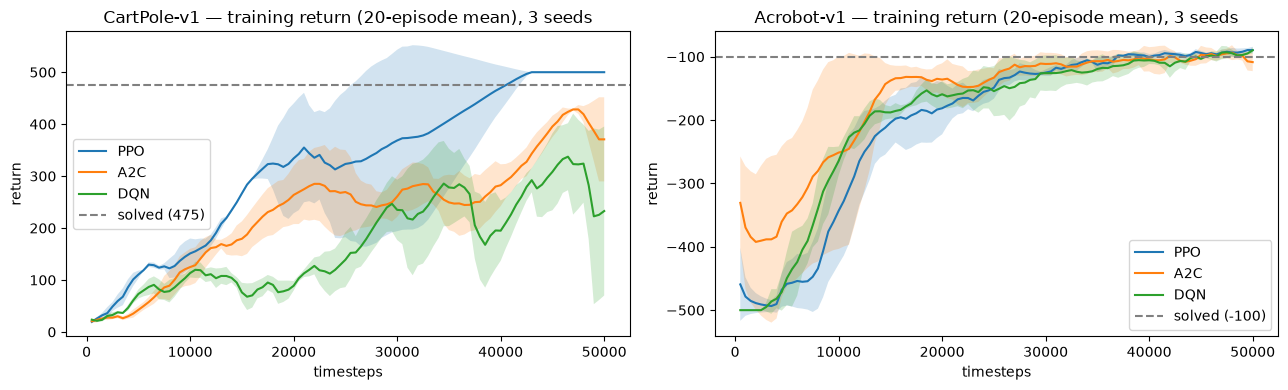

In [42]:
PROJECT_GRID = np.linspace(0, PROJECT_TIMESTEPS, 101)


def project_curve(history, window=20):
    steps, rets = history[:, 0], pd.Series(history[:, 1]).rolling(window, min_periods=1).mean().to_numpy()
    return np.where(PROJECT_GRID >= steps[0], np.interp(PROJECT_GRID, steps, rets), np.nan)


fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, env_id in zip(axes, THRESHOLDS):
    for algo_name in ALGORITHMS:
        curves = np.stack([project_curve(project_logs[(env_id, algo_name, s)]) for s in PROJECT_SEEDS])
        has_data = ~np.all(np.isnan(curves), axis=0)                   # skip grid points before any episode finished
        mean, std = np.nanmean(curves[:, has_data], axis=0), np.nanstd(curves[:, has_data], axis=0)
        ax.plot(PROJECT_GRID[has_data], mean, label=algo_name)
        ax.fill_between(PROJECT_GRID[has_data], mean - std, mean + std, alpha=0.2)
    ax.axhline(THRESHOLDS[env_id], ls="--", c="gray", label=f"solved ({THRESHOLDS[env_id]})")
    ax.set(title=f"{env_id} — training return (20-episode mean), {len(PROJECT_SEEDS)} seeds", xlabel="timesteps", ylabel="return")
    ax.legend()
plt.tight_layout()
plt.show()

### Step 4 — Final evaluation table

In [43]:
def steps_to_threshold(history, threshold, window=20):
    smoothed = pd.Series(history[:, 1]).rolling(window).mean().to_numpy()
    hit = np.flatnonzero(smoothed >= threshold)
    return history[hit[0], 0] if len(hit) else np.nan


summary_rows = []
for (env_id, algo_name), group in project.groupby(["env", "algorithm"]):
    reach = [steps_to_threshold(project_logs[(env_id, algo_name, s)], THRESHOLDS[env_id]) for s in PROJECT_SEEDS]
    summary_rows.append({
        "env": env_id, "algorithm": algo_name,
        "eval mean": group["eval_mean"].mean(),                      # mean over seeds of each agent's 20-episode eval
        "std (seeds)": group["eval_mean"].std(ddof=1),
        "seeds solved": int((group["eval_mean"] >= THRESHOLDS[env_id]).sum()),
        "steps to threshold": np.nanmean(reach) if np.any(~np.isnan(reach)) else np.nan,   # training curve, seeds that got there
        "sec/run": group["train_seconds"].mean(),
    })
summary = pd.DataFrame(summary_rows).set_index(["env", "algorithm"]).round(1)
summary

eval mean  std (seeds)  seeds solved  \
env         algorithm                                         
Acrobot-v1  A2C            -83.5          5.0             3   
            DQN            -81.0          4.9             3   
            PPO            -89.1          7.1             3   
CartPole-v1 A2C            387.2        195.3             2   
            DQN            381.7        204.9             2   
            PPO            500.0          0.0             3   

                       steps to threshold  sec/run  
env         algorithm                               
Acrobot-v1  A2C                   32149.5      2.0  
            DQN                   36069.0     16.4  
            PPO                   36214.7      2.8  
CartPole-v1 A2C                       NaN      1.3  
            DQN                       NaN     10.3  
            PPO                   32193.7      3.0

### Step 5 — Conclusions computed from the table

In [44]:
for env_id in THRESHOLDS:
    part = summary.loc[env_id]
    best = part["eval mean"].idxmax()
    most_stable = part["std (seeds)"].idxmin()
    fastest = part["sec/run"].idxmin()
    reached = part["steps to threshold"].dropna()
    print(f"■ {env_id}")
    print(f"  best final evaluation : {best} ({part.loc[best, 'eval mean']:.1f} ± {part.loc[best, 'std (seeds)']:.1f})")
    print(f"  most consistent seeds : {most_stable} (std {part.loc[most_stable, 'std (seeds)']:.1f})")
    print(f"  fastest wall-clock    : {fastest} ({part.loc[fastest, 'sec/run']:.1f} s per run, "
          f"slowest {part['sec/run'].idxmax()} {part['sec/run'].max():.1f} s)")
    if len(reached):
        print(f"  most sample-efficient : {reached.idxmin()} (training curve reached {THRESHOLDS[env_id]} after ~{reached.min():,.0f} steps)")
    else:
        print(f"  no algorithm's training curve reached {THRESHOLDS[env_id]} within {PROJECT_TIMESTEPS:,} steps")
    unsolved = part[part["seeds solved"] < len(PROJECT_SEEDS)].index.tolist()
    print(f"  not solved on every seed: {unsolved if unsolved else 'none'}")

gap = summary["std (seeds)"].max()
print(f"\nLargest seed-to-seed std in the table: {gap:.1f} return points — conclusions from a single seed could easily flip.")

■ CartPole-v1
  best final evaluation : PPO (500.0 ± 0.0)
  most consistent seeds : PPO (std 0.0)
  fastest wall-clock    : A2C (1.3 s per run, slowest DQN 10.3 s)
  most sample-efficient : PPO (training curve reached 475 after ~32,194 steps)
  not solved on every seed: ['A2C', 'DQN']
■ Acrobot-v1
  best final evaluation : DQN (-81.0 ± 4.9)
  most consistent seeds : DQN (std 4.9)
  fastest wall-clock    : A2C (2.0 s per run, slowest DQN 16.4 s)
  most sample-efficient : A2C (training curve reached -100 after ~32,150 steps)
  not solved on every seed: none

Largest seed-to-seed std in the table: 204.9 return points — conclusions from a single seed could easily flip.


**Stretch goals**
1. Add **5 more seeds** and report 95% bootstrap confidence intervals of the mean instead of ± std.
2. Double the budget to 100,000 steps — do the rankings change? (Sample efficiency vs final performance.)
3. Tune one algorithm with **Optuna** on *tuning seeds*, then re-evaluate on fresh seeds (see [Optuna](../12_AutoML_Experimentation/01_Optuna.ipynb)).
4. Add **`MountainCar-v0`** (sparse reward) — why does DQN with ε-greedy struggle there, and what does reward shaping or `MountainCarContinuous` + SAC change?

### 🗣️ How to talk about this in an interview
- "I compared PPO, A2C, and DQN on CartPole and Acrobot with an equal 50k-step budget, 3 seeds each, starting from RL Zoo hyperparameters, and evaluated each agent deterministically on held-out seeds."
- "I plotted learning curves from the actual Monitor logs with mean ± std bands, and separated final performance, seed-to-seed consistency, sample efficiency, and wall-clock time — they don't always pick the same winner."
- "Wall-clock differences come from how much gradient computation each algorithm does per environment step — DQN trains on replay mini-batches, A2C does one small update per 40-step rollout."
- "With only 3 seeds I'd call close results a tie; the next step is more seeds and confidence intervals."
- "The same PPO machinery — clipped updates, GAE, a critic — is what RLHF uses on language models."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What are the two key tricks in DQN and why is each needed?**

<details><summary>Show answer</summary>

- **30-second answer:** Experience replay stores transitions and trains on random mini-batches, which breaks the strong correlation between consecutive samples and reuses data. A target network — a periodically synced copy — computes the TD targets so the regression target doesn't move with every update. Without replay, SGD sees highly correlated data; without the target network, the network chases its own predictions and can diverge.
- **Go deeper:** Section 2 measured ~0.98 correlation between consecutive CartPole transitions vs ~0 after shuffling, and targets drifting when computed with the online network. Follow-ups: Double DQN (select with online, evaluate with target), dueling heads, prioritised replay, n-step returns, Huber loss.
- **❌ Common wrong answer:** "The target network is a second model you ensemble with" or "replay is for saving memory".

</details>

**Q2. Give the intuition behind the policy gradient theorem.**

<details><summary>Show answer</summary>

- **30-second answer:** $\nabla J = \mathbb{E}[\sum_t \nabla \log \pi(a_t \mid s_t)\,G_t]$: increase the log-probability of each action in proportion to the return that followed it. The log-derivative trick lets us estimate the gradient of an expectation from samples without differentiating the environment dynamics.
- **Go deeper:** It's unbiased but high-variance; use reward-to-go (causality), a baseline, and advantages. It's on-policy: samples must come from the current policy (or be corrected with importance ratios, as PPO does within a small trust region).
- **❌ Common wrong answer:** "You backpropagate the reward through the environment."

</details>

**Q3. Why do baselines and advantages reduce variance without adding bias?**

<details><summary>Show answer</summary>

- **30-second answer:** Subtracting a state-dependent baseline $b(s)$ adds $\mathbb{E}_a[\nabla \log \pi(a \mid s)]\,b(s) = 0$ to the expected gradient, so the mean is unchanged, but the magnitudes of the per-sample terms shrink. Using $V(s)$ gives the advantage $A = Q - V$: "better or worse than usual".
- **Go deeper:** In Section 4 the baseline cut the gradient variance several-fold on the bandit. In practice advantages come from a learned critic (A2C) or GAE(λ) (PPO), and are normalised per batch. The baseline must not depend on the action, or bias creeps in.
- **❌ Common wrong answer:** "The baseline makes the gradient more accurate by changing its expected value."

</details>

**Q4. What does PPO's clipping do, and why was it introduced?**

<details><summary>Show answer</summary>

- **30-second answer:** PPO maximises $\min(r_t A_t, \text{clip}(r_t, 1-\varepsilon, 1+\varepsilon)A_t)$ where $r_t$ is the new/old probability ratio. Once an action's probability has changed by more than ε in the helpful direction, the gradient is zero, so several epochs on the same batch can't move the policy too far. It's a simpler, first-order replacement for TRPO's KL-constrained update.
- **Go deeper:** Monitor `approx_kl` and `clip_fraction`; `target_kl` adds early stopping per update. The value function can also be clipped. Implementation details (advantage normalisation, orthogonal init, learning-rate annealing, gradient clipping) matter as much as the clip itself (Engstrom et al. 2020; "37 implementation details").
- **❌ Common wrong answer:** "It clips the gradients" (that's `max_grad_norm`) or "it clips the rewards".

</details>

**Q5. Why are on-policy methods less sample-efficient than off-policy ones?**

<details><summary>Show answer</summary>

- **30-second answer:** On-policy methods (REINFORCE, A2C, PPO) estimate gradients with data from the *current* policy, so after an update the old data is stale and discarded. Off-policy methods (DQN, SAC) learn from any past data in a replay buffer, reusing each transition many times.
- **Go deeper:** PPO partially recovers efficiency with importance ratios over a few epochs inside a trust region. On-policy methods are often more stable and parallelise easily, so they win when simulation is cheap (games, RLHF with fast generation); off-policy wins when environment steps are expensive (real robots).
- **❌ Common wrong answer:** "On-policy methods can't use neural networks" or "off-policy means offline".

</details>

**Q6. What role does the entropy term play in SAC?**

<details><summary>Show answer</summary>

- **30-second answer:** SAC maximises reward plus α times the policy's entropy, so it prefers policies that succeed while staying as random as possible. That gives principled exploration, robustness, and avoids premature collapse. α is tuned automatically to reach a target entropy (−|A| by default).
- **Go deeper:** The critic uses "soft" Bellman targets $r + \gamma(\min_i Q_i(s', a') - \alpha \log \pi(a' \mid s'))$ with twin critics and polyak-averaged targets; the actor is a tanh-squashed Gaussian trained with the reparameterisation trick. PPO/A2C use an entropy *bonus* in the loss for a similar reason.
- **❌ Common wrong answer:** "Entropy is a regulariser on the network weights."

</details>

**Q7. Walk me through RLHF.**

<details><summary>Show answer</summary>

- **30-second answer:** (1) Supervised fine-tune a base model on demonstrations. (2) Collect human comparisons of model answers and train a reward model with a Bradley–Terry loss. (3) Optimise the policy with PPO to maximise reward minus a KL penalty to the SFT (reference) model, treating each generated token as an action.
- **Go deeper:** PPO needs policy, reference, reward, and value models in memory; the KL term prevents reward hacking and language drift; rewards are usually given at the end of the sequence with per-token KL. Failure modes: reward-model over-optimisation (Goodhart), verbosity bias, sycophancy.
- **❌ Common wrong answer:** "RLHF means humans label every token" or "the reward model is the final chatbot".

</details>

**Q8. Why can DPO skip the reward model and the RL loop? When would you still use PPO or GRPO?**

<details><summary>Show answer</summary>

- **30-second answer:** The KL-regularised RLHF objective has a closed-form optimal policy, so the reward can be expressed as $\beta \log(\pi_\theta/\pi_\text{ref})$. Substituting into the Bradley–Terry loss gives a classification loss on preference pairs that trains the policy directly — no reward model, no sampling, no critic.
- **Go deeper:** DPO is offline and simpler/cheaper, but it can't benefit from fresh on-policy samples or non-preference rewards. Online methods (PPO, GRPO) shine with verifiable rewards (maths, code tests) and iterative exploration; GRPO removes the critic by normalising rewards within a group of samples per prompt.
- **❌ Common wrong answer:** "DPO doesn't need a reference model."

</details>

### 💻 Coding

**Q9. Write the REINFORCE-with-baseline loss in PyTorch for one episode.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  log_probs = Categorical(logits=policy(states)).log_prob(actions)
  values = value_net(states).squeeze(-1)
  adv = returns - values.detach()
  loss = -(log_probs * adv).mean() + 0.5 * F.mse_loss(values, returns)
  ```
- **Go deeper:** `returns` is the discounted reward-to-go (bootstrapped with V on truncation). `detach` the baseline in the policy term so the actor loss doesn't train the critic. Normalise advantages; add an entropy bonus if exploration collapses.
- **❌ Common wrong answer:** Forgetting the minus sign (gradient *descent* on a quantity you want to maximise) or using the whole-episode return for every step.

</details>

**Q10. Implement PPO's clipped policy loss.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  ratio = torch.exp(new_log_prob - old_log_prob)
  loss = -torch.min(ratio * adv, torch.clamp(ratio, 1 - eps, 1 + eps) * adv).mean()
  ```
- **Go deeper:** Compute the ratio from log-probs for numerical stability; `old_log_prob` comes from the rollout and has no gradient; normalise `adv` per mini-batch; log `approx_kl = ((ratio - 1) - log ratio).mean()` and the clip fraction.
- **❌ Common wrong answer:** Using `max` instead of `min`, or clipping the advantage instead of the ratio.

</details>

### 🐛 Debugging Scenarios

**Q11. Your RL agent gets a very high training reward, but it behaves absurdly — e.g. a boat circles collecting points instead of finishing the race. What's going on?**

<details><summary>Show answer</summary>

- **30-second answer:** Reward hacking: the agent maximises the reward you *specified*, not the goal you *meant*. Fix the reward (sparse true objective, potential-based shaping, penalties for the exploit), evaluate on the true task metric, and inspect behaviour (videos, trajectories), not just curves.
- **Go deeper:** OpenAI's CoastRunners boat is the classic example. In RLHF the policy exploits reward-model weaknesses (length, flattery) — mitigations are a KL penalty, reward-model ensembles or retraining on new policy samples, and held-out human evals.
- **❌ Common wrong answer:** "Train longer" or "increase the learning rate".

</details>

**Q12. PPO's reward climbs, then suddenly collapses and doesn't recover. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** Look at `approx_kl`, `clip_fraction`, entropy, and the value loss in the logs. Typical causes: learning rate too high, too many epochs or too small mini-batches (overfitting each rollout), no advantage normalisation, or entropy collapsing. Lower the LR (or anneal it), set `target_kl`, reduce `n_epochs`, increase `n_steps`.
- **Go deeper:** Also check observation/reward scaling (`VecNormalize`), bugs in truncation handling, and whether the evaluation env differs from training. Always compare across seeds — one collapsed seed may be variance, all seeds collapsing is a bug.
- **❌ Common wrong answer:** "PPO is unstable, switch algorithms" without inspecting diagnostics.

</details>

**Q13. A teammate shows "8 vectorized envs trained 5× faster than 1 env" and a PPO learning curve that looks too smooth. What questions do you ask?**

<details><summary>Show answer</summary>

- **30-second answer:** Were total timesteps, rollout size (`n_envs × n_steps`), mini-batch size, and epochs the same — i.e. the same number of gradient updates? Was wall-clock measured around `learn` only? Is the curve read from Monitor/EvalCallback logs over several seeds, or typed in / smoothed beyond recognition? Was an early-stopping callback actually passed to `learn`?
- **Go deeper:** Pitfall 3 showed an "8-env" run consuming 32,768 steps with 20 updates vs 100 updates for 1 env. Ask for `model.num_timesteps`, `model._n_updates`, raw logs, and seed counts.
- **❌ Common wrong answer:** Accepting the speed-up because "parallel is obviously faster".

</details>

### 🏗️ Design

**Q14. How do you evaluate and compare RL agents so the conclusion holds up?**

<details><summary>Show answer</summary>

- **30-second answer:** Fixed timestep budget per algorithm; several training seeds (≥ 3, ideally 5–10); a separate, seeded evaluation env; deterministic policy over many episodes; report mean ± std or bootstrap CIs, learning curves from logs, and a baseline; tune on different seeds than you report.
- **Go deeper:** Separate final performance, sample efficiency (steps to threshold, area under curve), wall-clock cost, and robustness (worst seed). For production, add safety constraints, off-policy evaluation on logged data, and shadow/A-B deployment. Agarwal et al. (2021) recommend interquartile mean and stratified bootstrap CIs.
- **❌ Common wrong answer:** "Pick the run with the best curve."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal.

**1.** PPO with `n_envs=4` and `n_steps=256` — how many timesteps are in one rollout?
<details><summary>Answer</summary>

`1024` — `n_steps` is per environment.
</details>

**2.** PPO objective for ratio `1.5`, advantage `+2`, `clip_range=0.2`?
<details><summary>Answer</summary>

`2.4` — min(1.5·2, 1.2·2).
</details>

**3.** A DQN transition has `terminated=True`. What is its target?
<details><summary>Answer</summary>

Just the reward `r` — no bootstrap term. (If it were only *truncated*, SB3 would still bootstrap.)
</details>

**4.** Does subtracting a state-dependent baseline change the expected policy gradient?
<details><summary>Answer</summary>

No — it only lowers variance, because $\mathbb{E}_a[\nabla \log \pi(a \mid s)] = 0$.
</details>

**5.** What does `evaluate_policy(model, env, n_eval_episodes=10)` return by default, and how many values does a SB3 `VecEnv.step` return?
<details><summary>Answer</summary>

`(mean_reward, std_reward)`; a VecEnv `step` returns 4 values `(obs, rewards, dones, infos)` and auto-resets finished envs.
</details>

## 📚 Resources

### 📖 Official Docs
- [Stable-Baselines3 documentation](https://stable-baselines3.readthedocs.io/en/master/) — algorithms, API, and examples
- [SB3 — Reinforcement Learning Tips and Tricks](https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html) — how to choose algorithms, normalise, and evaluate
- [SB3 — Callbacks](https://stable-baselines3.readthedocs.io/en/master/guide/callbacks.html) — `EvalCallback`, stopping callbacks, custom callbacks
- [SB3 — Vectorized Environments](https://stable-baselines3.readthedocs.io/en/master/guide/vec_envs.html) — the 4-tuple step API, auto-reset, `terminal_observation`
- [RL Baselines3 Zoo](https://github.com/DLR-RM/rl-baselines3-zoo) — tuned hyperparameters for many env/algorithm pairs

### 🎥 Videos
- [Arxiv Insights — An introduction to Policy Gradient methods](https://www.youtube.com/watch?v=5P7I-xPq8u8) (20 min) — clear visual intuition for policy gradients and PPO's clipping; watch after Section 6
- [Pieter Abbeel — Foundations of Deep RL (6-lecture series)](https://www.youtube.com/playlist?list=PLwRJQ4m4UJjNymuBM9RdmB3Z9N5-0IlY0) (6 lectures, ~1 h each) — MDPs through DQN, policy gradients, TRPO/PPO, DDPG/SAC, and model-based RL from one of the field's leading researchers
- [Umar Jamil — Reinforcement Learning from Human Feedback explained with math derivations and the PyTorch code](https://www.youtube.com/watch?v=qGyFrqc34yc) (2 h 15 min) — RLHF and PPO for language models, derived step by step

### 📄 Papers
- [Mnih et al. (2015) — Human-level control through deep reinforcement learning](https://www.nature.com/articles/nature14236) — DQN
- [Schulman et al. (2017) — Proximal Policy Optimization Algorithms](https://arxiv.org/abs/1707.06347) — PPO
- [Schulman et al. (2016) — High-Dimensional Continuous Control Using Generalized Advantage Estimation](https://arxiv.org/abs/1506.02438) — GAE
- [Mnih et al. (2016) — Asynchronous Methods for Deep Reinforcement Learning](https://arxiv.org/abs/1602.01783) — A3C/A2C
- [Haarnoja et al. (2018) — Soft Actor-Critic](https://arxiv.org/abs/1801.01290) — SAC
- [Ouyang et al. (2022) — Training language models to follow instructions with human feedback](https://arxiv.org/abs/2203.02155) — InstructGPT / RLHF
- [Rafailov et al. (2023) — Direct Preference Optimization](https://arxiv.org/abs/2305.18290) — DPO
- [Shao et al. (2024) — DeepSeekMath](https://arxiv.org/abs/2402.03300) — introduces GRPO
- [Henderson et al. (2018) — Deep Reinforcement Learning that Matters](https://arxiv.org/abs/1709.06560) — seeds, variance, and reporting

### 📘 Books & Courses
- [OpenAI Spinning Up — Part 3: Intro to Policy Optimization](https://spinningup.openai.com/en/latest/spinningup/rl_intro3.html) — the policy-gradient derivation, reward-to-go, and baselines
- [Hugging Face Deep RL Course](https://huggingface.co/learn/deep-rl-course/unit0/introduction) — free units on DQN, policy gradients, PPO, and more, with SB3 notebooks
- [The 37 Implementation Details of PPO](https://iclr-blog-track.github.io/2022/03/25/ppo-implementation-details/) — why PPO implementations differ and what actually matters
- [Reinforcement Learning from Human Feedback (Nathan Lambert, free book)](https://rlhfbook.com/) — RLHF, reward models, DPO, and RL for reasoning
- [Hugging Face — Illustrating RLHF](https://huggingface.co/blog/rlhf) — a short, well-illustrated overview

### 🏋️ Practice
- [CleanRL](https://github.com/vwxyzjn/cleanrl) — single-file DQN/PPO/SAC implementations: read one, then re-implement it
- [Hugging Face TRL](https://huggingface.co/docs/trl/index) — DPO, GRPO, and PPO trainers for language models, used in the Fine-Tuning notebook

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Function approximation | generalise across huge/continuous state spaces | MLP `obs → Q-values / action probs / V(s)` |
| DQN | Q-learning with a network | target $r + \gamma(1-\text{term})\max_{a'}Q_{\bar\theta}(s',a')$; replay buffer + target net; `DQN("MlpPolicy", env)` |
| Policy gradient | push up log-prob of actions by their return | $\nabla J = \mathbb{E}[\nabla\log\pi(a_t \mid s_t)\,G_t]$ |
| Baseline / advantage | cut variance, keep bias zero | $A_t = G_t - V(s_t)$; normalise per batch |
| A2C | actor + critic, n-step advantages | `A2C("MlpPolicy", vec_env)`; loss = actor + $c_v$·critic − $c_e$·entropy |
| PPO | safe multi-epoch updates | $\min(rA,\ \text{clip}(r,1\pm\varepsilon)A)$; `n_steps`, `batch_size`, `n_epochs`, `clip_range` |
| GAE | blend n-step advantages | $\hat A_t = \delta_t + \gamma\lambda(1-d)\hat A_{t+1}$ |
| SAC | off-policy continuous control with entropy | $r + \alpha\mathcal{H}(\pi)$; twin critics; `ent_coef="auto"` |
| Evaluate | honest numbers | `evaluate_policy(model, separate_env, n_eval_episodes=20, deterministic=True)` |
| Save / load | persist agents | `model.save(path)`, `PPO.load(path)` |
| Callbacks | eval, early stop, custom logic | `learn(callback=EvalCallback(env, callback_on_new_best=StopTrainingOnRewardThreshold(...)))` |
| Logs & curves | real learning curves | `make_vec_env(..., monitor_dir=...)`, `load_results(dir)`, `evaluations.npz` |
| Vectorized envs | batch environment steps | `make_vec_env(id, n_envs, vec_env_cls=DummyVecEnv/SubprocVecEnv)`; compare with equal timesteps & updates |
| Seeds | trustworthy comparisons | ≥ 3 seeds, mean ± std, separate eval seeds |
| RLHF / DPO / GRPO | RL for LLMs | RM + PPO with KL · $-\log\sigma(\beta[\Delta\log\text{ratio}])$ · group-normalised rewards, no critic |

## ➡️ What's Next

**[08 · LLM APIs and Prompting](../08_Generative_AI_LLM/01_LLM_APIs_and_Prompting.ipynb)** — you now know how RLHF, DPO, and GRPO shape a language model's behaviour; next you'll work with those models directly: calling LLM APIs, prompting, structured outputs, and streaming — and later fine-tune one yourself in [Fine-Tuning with LoRA and DPO](../08_Generative_AI_LLM/07_Fine_Tuning_LoRA_and_DPO.ipynb).